# Predicting Sales from Campaign Data
## Step-by-step study notes for a first machine-learning case study

**Business question:** given an influencer's followers, engagement rate, campaign spend and content quality, how many product units should we expect to sell?

This notebook shows the full analytical process: understand the data, identify errors, compare cleaning assumptions, explore relationships, construct features, compare models, tune promising approaches, evaluate honestly and interpret the results.

Each section explains **what we are doing, why it matters, what the output shows and what decision follows**. All transformations, model code, tables, predictions and plots are contained in this notebook. The only input files needed are the two supplied CSVs.

**Sections:** 1. Problem and validation design · 2. Data understanding · 3. Cleaning and preprocessing · 4. Exploratory analysis · 5. Model experiments · 6. Evaluation · 7. Interpretation and robustness · 8. Final predictions and reusable function · 9. Summary and recommendations.

**How to study this notebook:** read the question above a code cell, run the cell, inspect its output, and read the observation below it. Do not worry about understanding every scikit-learn option on your first pass. Focus on what goes in, what changes and what comes out.

**Naming convention:** `*_campaigns` means a table of campaign inputs; `*_sales` means known outcomes; `*_predictions` means model estimates; `*_scores` or `*_results` means a comparison. `fit` learns from training data, while `predict` uses what has already been learned.

## Results at a glance — return here after working through the notes

| Measure | Result |
|---|---:|
| Selected model | Huber tuned |
| Untouched holdout RMSE | 2,156.6 units |
| Untouched holdout MAE | 1,691.7 units |
| Untouched holdout R² | 0.415 |
| RMSE reduction versus mean baseline | 23.5% |
| Final test predictions | 2,000 |

**Main insight:** followers and ad spend carry the most predictive information, followed by content quality and engagement. Huber and Ridge are practically tied; more flexible models do not improve development CV. Accuracy is moderate, with substantial campaign-level uncertainty.

**Critical qualification:** all 160 originally missing follower records fell into the initial holdout, while development and calibration had none. This input-distribution imbalance makes the holdout harder and weakens interval transfer. The score above is retained. A separately labelled, availability-balanced post-selection diagnostic averages RMSE 1,999.6 and R² 0.492; it is not an independent replacement score.

**Use:** screen comparable campaigns, improve source-unit validation and review incomplete records. Predictions describe associations, not causal sales lift or incremental ROI. Test-set R² and RMSE cannot be measured because test labels are absent.

## 1. Understand the problem and define a fair evaluation

**Sources:** `messy_train_data.csv` and `messy_test_data.csv` are the sole data sources. The supplied *Approach document: Predicting Sales from Campaign Data* (Sections A–F) informs the analytical scope, not the results. `Practice1.ipynb`, `Practice2.ipynb` and `Practice3.ipynb` inform the explanatory style: inspect variables, justify preprocessing, show visual evidence and finish with recommendations. Their code and conclusions are not reused as evidence for this dataset.

**Prediction timing matters.** Historical engagement, spend and content quality may be measured after a campaign. This solution assumes those four inputs are available when a prediction is requested. Pre-launch forecasts using planned spend and estimated quality require a separate prospective validation. Actual campaign end dates and free-text notes are excluded from predictive features because their availability and provenance are unclear. ID is retained only to align predictions.

**Validation contract, fixed before model comparison:** randomly reserve 20% as the final holdout; split the remaining 80% into development (64% overall) and interval calibration (16%). All algorithm, feature and hyperparameter choices use only five-fold development CV. Calibration labels are used only for interval width. Inspect final holdout performance once after freezing the winner. A later chronological backtest and corruption test are diagnostic, not further selection opportunities.

RMSE in units is the primary objective because large misses matter for inventory planning. MAE describes a typical absolute error, and R² compares squared error with a mean predictor. Scores on the unlabeled test CSV are unavailable. No target values are imputed, clipped, rounded or transformed for evaluation.

**How to use this notebook:** run cells from top to bottom with the supplied CSVs in the same folder. The code uses pandas, NumPy, matplotlib, seaborn and scikit-learn. A fixed random seed makes the experiments reproducible. No helper module or previously saved model is needed.

### What kind of machine-learning problem is this?

This is **supervised regression**. Historical campaigns contain both input attributes and observed sales. The model learns a relationship between them, then uses that relationship to predict sales for campaigns without labels.

| Variable | Meaning | Role in this analysis |
|---|---|---|
| Followers | Influencer audience size | Predictor after resolving units and invalid values |
| EngagementRate (%) | Engagement as percentage points | Predictor: `3.2` means 3.2%, not 320% |
| AdSpend (GBP) | Campaign spending in pounds | Predictor after parsing currency strings |
| ContentQuality | Rating on a 1–10 scale | Predictor; rating consistency matters |
| Sales (Units) | Units sold | Target to predict |
| ID | Campaign identifier | Match each test prediction to its original row |
| Timestamp | Actual campaign end date | Explore time patterns and backtest; exclude from the predictor set |
| Notes | Administrative free text | Exclude because its meaning and prediction-time availability are unclear |

**A forecast is not a causal explanation.** If higher-spend campaigns sell more, other factors may explain part of that association. Predicting sales is different from estimating how many extra sales a spending increase would cause.

### How will we judge success?

For a campaign selling 10,000 units, a forecast of 11,500 has an error of 1,500 units.

- **MAE:** average absolute error. Easy to interpret in units sold.
- **RMSE:** square the errors, average them, then take the square root. A few large mistakes increase this metric more strongly than MAE. This is the main model-selection criterion.
- **R²:** the fraction of variation explained relative to predicting the evaluation set's mean. A value of 1 is perfect, 0 matches that reference, and a negative value is worse. **R² of 0.415 does not mean 41.5% of predictions are correct.**

A good model should beat a simple baseline, work across different validation folds and remain useful when inputs are messy. Complexity alone is not a success criterion.

### Tiny glossary before we begin

| Term | Plain-language meaning | Example here |
|---|---|---|
| Row / observation | One item we learn from | One campaign |
| Feature / predictor | An input available to the model | Followers |
| Target / label | The answer known for historical rows | Sales units |
| Training / fitting | Learning a relationship from examples | Learn how inputs relate to sales |
| Validation | Trying that relationship on examples not used to fit it | One held-out CV fold |
| Hyperparameter | A setting chosen before fitting | Ridge shrinkage strength |
| Overfitting | Learning quirks that do not carry over | Low training error, higher validation error |
| Leakage | Using information that would not be available in a fair prediction | Imputing with validation statistics |
| Imputation | Replacing a missing input with a stated estimate | Training-fold median spend |

**Checkpoint:** in the test file, inputs exist but the answers do not. That is why we can generate forecasts but cannot measure test accuracy.

### Import tools for tables, numbers and charts

`pandas` handles tables, `numpy` handles numerical operations, and matplotlib/seaborn display plots.

In [1]:
from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict, GridSearchCV, TimeSeriesSplit

### Import tools for fair model comparison

These tools split data, build pipelines and fit competing regression approaches.

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor, VotingRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
RANDOM_SEED = 42

### Set up a reproducible analysis

The random seed fixes random choices. Chart settings only control presentation.

In [3]:
DATA_FOLDER = Path.cwd()
if not (DATA_FOLDER / "messy_train_data.csv").exists():
    raise FileNotFoundError("Run the notebook from the folder containing the supplied CSVs.")
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.max_columns", 15)

### Use the same score definitions throughout

A small helper avoids accidentally calculating a metric differently in different experiments.

In [4]:
def display_figure(figure):
    figure.tight_layout()
    plt.show()

In [5]:
def calculate_regression_scores(actual_sales, predicted_sales):
    return {"RMSE": float(np.sqrt(mean_squared_error(actual_sales, predicted_sales))),
            "MAE": float(mean_absolute_error(actual_sales, predicted_sales)), "R2": float(r2_score(actual_sales, predicted_sales))}

### A visual map of the case study

Read left to right. We choose a model using development data, evaluate it once on the holdout, then refit it for final predictions.

In [6]:
def draw_process_diagram(labels, title):
    figure, axis = plt.subplots(figsize=(13, 2.4))
    axis.set(xlim=(-0.6, len(labels)-0.4), ylim=(-0.6, 0.6), title=title)
    axis.axis("off")
    for step_number, label in enumerate(labels):
        axis.text(step_number, 0, label, ha="center", va="center",
                  bbox=dict(boxstyle="round,pad=0.5", fc="#E6F2FA", ec="#276E90"))
        if step_number < len(labels)-1:
            axis.annotate("", (step_number+0.63, 0), (step_number+0.36, 0),
                          arrowprops=dict(arrowstyle="->", color="#276E90"))
    display_figure(figure)

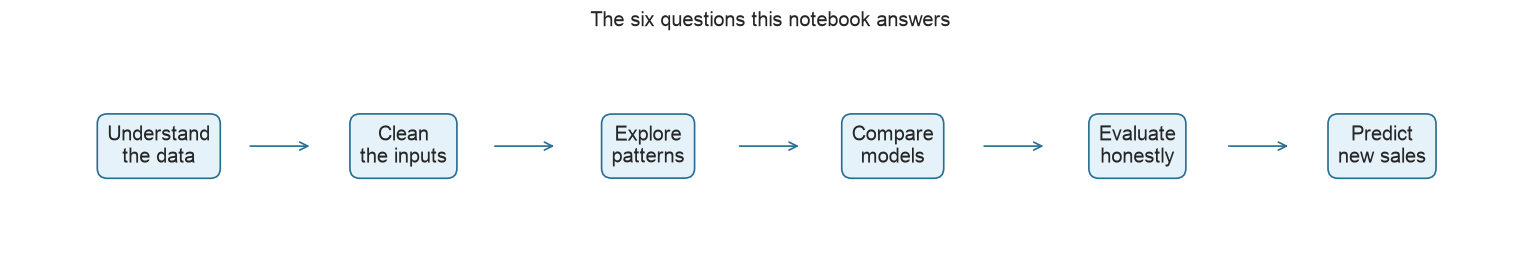

In [7]:
workflow_steps = ["Understand\nthe data", "Clean\nthe inputs", "Explore\npatterns", "Compare\nmodels", "Evaluate\nhonestly", "Predict\nnew sales"]
draw_process_diagram(workflow_steps, "The six questions this notebook answers")

## 2. Load, audit and reserve evaluation data

Each row is one campaign. Check the target, identifiers, duplicates, schema and date coverage before any modeling. Exact repeated records would overstate validation performance; conflicting repeated IDs would require source reconciliation. Missing predictors stay in the dataset so predictions remain possible for incomplete future records.

### Read the two tables and identify the predictors

In [8]:
training_campaigns = pd.read_csv(DATA_FOLDER / "messy_train_data.csv")
test_campaigns = pd.read_csv(DATA_FOLDER / "messy_test_data.csv")
TARGET_COLUMN = "Sales (Units)"
PREDICTOR_COLUMNS = ["Followers", "EngagementRate (%)", "AdSpend (GBP)", "ContentQuality"]
assert set(PREDICTOR_COLUMNS + [TARGET_COLUMN, "ID", "Timestamp", "Notes"]) <= set(training_campaigns)
assert set(PREDICTOR_COLUMNS + ["ID"]) <= set(test_campaigns)
assert TARGET_COLUMN not in test_campaigns, "Do not use hidden test labels."
training_sales = pd.to_numeric(training_campaigns[TARGET_COLUMN], errors="coerce")
assert training_sales.notna().all() and np.isfinite(training_sales).all() and (training_sales >= 0).all()

### Check the target and campaign identifiers

In [9]:
assert training_campaigns.ID.is_unique and test_campaigns.ID.is_unique
assert set(training_campaigns.ID).isdisjoint(set(test_campaigns.ID))
assert not training_campaigns.duplicated().any()
assert not training_campaigns[PREDICTOR_COLUMNS + ["Timestamp"]].duplicated().any(), "Review repeated campaign signatures before splitting."
display(pd.DataFrame({"rows": [len(training_campaigns), len(test_campaigns)], "columns": [training_campaigns.shape[1], test_campaigns.shape[1]],
    "start_date": [training_campaigns.Timestamp.min(), test_campaigns.Timestamp.min()],
    "end_date": [training_campaigns.Timestamp.max(), test_campaigns.Timestamp.max()]}, index=["Train", "Test"]))
display(training_campaigns.head())

,rows,columns,start_date,end_date
Train,8000,8,2021-01-01,2023-09-27
Test,2000,7,2021-01-01,2023-09-27


,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Sales (Units),ID,Timestamp,Notes
0,106572.0,2.573174871146172,2614.3781948587675,5.275680,6340,9254,2021-11-27,Pending
1,77583.0,0.9394984315675532,4975.962514379572,8.756268,5793,1561,2022-02-13,Review
2,92832.0,2.1761012652155296,4107.769534318886,6.454727,8104,1670,2023-09-25,Pending
3,53565.0,1.4783757541486553,4293.330464613049,4.312813,7293,6087,2023-02-15,Review
4,121079.0,3.3741976179329356,5343.549440897207,3.769047,14396,6669,2023-05-28,NaN


### Inspect the shape and first few rows

In [10]:
display(pd.DataFrame({"dtype": training_campaigns.dtypes.astype(str), "missing_train": training_campaigns.isna().sum(),
                      "missing_test": test_campaigns.isna().sum(), "unique_train": training_campaigns.nunique()}))

,dtype,missing_train,missing_test,unique_train
AdSpend (GBP),object,159,40.0,7815
ContentQuality,float64,160,40.0,7840
EngagementRate (%),object,160,40.0,7800
Followers,float64,160,40.0,7403
ID,int64,0,0.0,8000
Notes,object,2652,660.0,4
Sales (Units),int64,0,NaN,5582
Timestamp,object,0,0.0,1000


### Read the initial audit

There are **8,000 labelled campaigns** and **2,000 unlabeled campaigns**. The target has no missing or negative values, so every training outcome can be retained. IDs are unique and do not overlap between files; exact repeated campaign signatures are also checked.

Each core predictor has approximately 2% missing cells. This is not the same as saying only 2% of campaigns are incomplete: different fields may be missing on different rows. `Notes` has many missing values, but it is excluded for availability and meaning reasons rather than simply because it is incomplete.

The raw engagement and spend columns contain strings, so directly feeding them into a regression model would fail. Numeric-looking follower values also need inspection: a numeric dtype does not establish that units are consistent.

### Reserve separate data for choosing, calibrating and evaluating the model

1. **Development: 5,120 campaigns.** Explore sales relationships and choose models with five-fold cross-validation.
2. **Calibration: 1,280 campaigns.** Estimate prediction-interval width after model selection.
3. **Holdout: 1,600 campaigns.** Evaluate the frozen model without changing it afterward.

In five-fold cross-validation, one fifth of development data is held out at a time, while the other four fifths train the model. Every development row is validated once. Preprocessing must also learn only from each fold's training rows; otherwise validation information could influence the model.

The original split is retained throughout this case study. A missing-follower imbalance discovered during evaluation is discussed explicitly later; we do not replace the holdout to obtain a better score.

### Create the three data subsets

In [11]:
development_calibration_indices, holdout_indices = train_test_split(training_campaigns.index, test_size=.20, random_state=RANDOM_SEED)
development_indices, calibration_indices = train_test_split(development_calibration_indices, test_size=.20, random_state=RANDOM_SEED + 1)
development_campaigns, development_sales = training_campaigns.loc[development_indices].drop(columns=TARGET_COLUMN), training_sales.loc[development_indices]
calibration_campaigns, calibration_sales = training_campaigns.loc[calibration_indices].drop(columns=TARGET_COLUMN), training_sales.loc[calibration_indices]
holdout_campaigns, holdout_sales = training_campaigns.loc[holdout_indices].drop(columns=TARGET_COLUMN), training_sales.loc[holdout_indices]
development_folds = list(KFold(5, shuffle=True, random_state=RANDOM_SEED).split(development_campaigns))
print(f"Development: {len(development_campaigns):,}; calibration: {len(calibration_campaigns):,}; sealed holdout: {len(holdout_campaigns):,}")
print("No ID overlap across splits:", len(set(development_indices) & set(holdout_indices)) == 0)

Development: 5,120; calibration: 1,280; sealed holdout: 1,600
No ID overlap across splits: True


### Visualize the three roles of labelled data

These are separate jobs: choose the model, calibrate an interval, and evaluate it. The unlabeled test rows are a fourth destination, not a fourth labelled split.

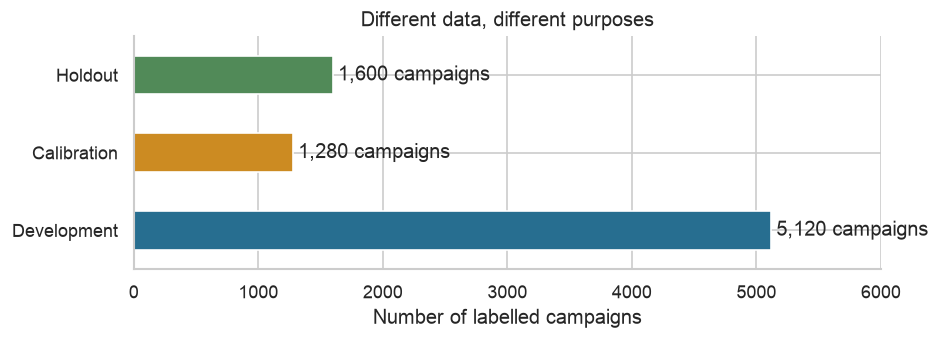

In [12]:
split_sizes = pd.Series({"Development": len(development_campaigns), "Calibration": len(calibration_campaigns), "Holdout": len(holdout_campaigns)})
figure, axis = plt.subplots(figsize=(8, 3))
split_sizes.plot.barh(ax=axis, color=["#276E90", "#CC8B22", "#518A58"])
for position, count in enumerate(split_sizes):
    axis.text(count+40, position, f"{count:,} campaigns", va="center")
axis.set(xlim=(0, 6000), xlabel="Number of labelled campaigns", title="Different data, different purposes")
display_figure(figure)

### Observations and leakage controls

The supplied test set has no sales labels, so it is a prediction destination, not an evaluation set. Both files cover overlapping historical dates; random validation addresses that competition setting. A chronological check later addresses the harder question of predicting later campaigns. No influencer identifier is supplied, so repeated creators cannot be grouped and independence across creators cannot be verified.

Full-file schema and missingness checks are permitted here, but target relationships, feature assumptions and model selection below use development data only. Dates, notes and IDs do not enter training. Full training labels are used only for the final production refit after evaluation is complete.

## 3. Auditable cleaning and feature construction

| Issue | Rule | Why and limitation |
|---|---|---|
| Currency and separators | Parse GBP/£, commas, spaces and explicit K/M suffixes | Keep monetary values in pounds; unsupported text becomes missing rather than being guessed |
| Engagement formats | `3.2%` and `3.2` both mean 3.2 percentage points | Bare `0.032` stays 0.032%; a fraction-to-percent conversion needs a source contract |
| Small unmarked follower counts | Compare multiplying positive bare counts below 1,000 by 1,000, keeping them literally, and treating them as missing | The problem explicitly mentions thousands; this is a dataset-specific assumption, not a universal Instagram rule |
| Invalid physical values | Negative followers/spend, engagement outside 0–100, quality outside 1–10 → missing | Do not invent a replacement or take absolute values |
| Extreme follower/spend values | Above Q3 + 10×IQR on the fitting fold → missing | A generous, learned upper bound catches orders-of-magnitude corruption; it can also flag legitimate new high-value campaigns |
| Missing predictors | Fold-fitted median plus a flag per original feature | Preserve rows and identify uncertainty from unavailable inputs |
| Target | Require valid nonnegative labels; retain all supplied sales | Removing difficult outcomes would make evaluation artificially easy |

The transformer below is fitted **inside every CV pipeline**. Parsing and physical constraints are deterministic; fences and imputation are learned on the fitting fold only. Feature engineering adds logs, estimated engaged audience, spend×quality, engagement×quality and spend per follower. These are hypotheses tested against the four-feature baseline. No feature uses sales, even indirectly. Division has a protected denominator.

### 3.1 Convert messy strings into numbers

The parser below handles supported formats explicitly. For example, `£5,000` becomes `5000`, `120k` followers becomes `120000`, and `3.2%` becomes `3.2` percentage points. It checks the entire string: `12 cats` is not silently interpreted as 12.

A string that cannot be understood becomes a missing value. This is preferable to inventing a number. The original DataFrame is not overwritten, so we can compare raw and cleaned records.

The code is defined here, directly in the notebook.

#### Remove only formatting that we understand

We preserve the meaning of the number. Percent values stay in percentage points; currency values stay in GBP.

In [13]:
import re
from sklearn.base import BaseEstimator, TransformerMixin

def normalize_numeric_text(value, feature_name):
    text = str(value).strip().lower().replace(",", "").replace(" ", "")
    if feature_name == "AdSpend (GBP)":
        text = text.replace("£", "").replace("gbp", "")
    if feature_name == "EngagementRate (%)" and text.endswith("%"):
        text = text[:-1]
    return text

#### Recognize a number and an optional unit suffix

The pattern checks the entire value, including an optional decimal or scientific notation. `k` means thousand and `m` means million. Unsupported text becomes missing.

In [14]:
def parse_value(value, feature_name):
    if pd.isna(value):
        return np.nan
    text = normalize_numeric_text(value, feature_name)
    pattern = r"([+-]?(?:\d+(?:\.\d*)?|\.\d+)(?:e[+-]?\d+)?)([km]?)"
    matched_number = re.fullmatch(pattern, text)
    if matched_number is None:
        return np.nan
    suffix = matched_number.group(2)
    if suffix and feature_name not in ("Followers", "AdSpend (GBP)"):
        return np.nan
    multiplier = {"": 1, "k": 1000, "m": 1000000}[suffix]
    number = float(matched_number.group(1)) * multiplier
    return number if np.isfinite(number) else np.nan

### 3.2 Resolve units and flag invalid or extreme values

`CampaignCleaner` is a scikit-learn transformer. Its two methods have distinct responsibilities:

- **`fit`** learns upper bounds for followers and spend using only the current training subset.
- **`transform`** applies parsing, the selected follower-unit rule, physical validity checks and the learned bounds to any new rows.

The outlier cutoff is **Q3 + 10 × IQR**, where IQR = Q3 − Q1. The multiplier is intentionally generous: ordinary high-performing campaigns should remain, while billion-scale corruptions should not dominate a regression. It is an assumption, not a universal business limit. Flagged values become missing rather than being replaced with the cutoff, because a corrupted billion-scale value tells us little about the true original value.

For bare follower values below 1,000, we will compare three policies: keep the value, mark it missing, or multiply it by 1,000. Explicit `k` and `m` suffixes already state the units and are not multiplied twice.

#### Check that the required inputs exist

Missing *cells* are allowed. A missing *column* means we do not know which measurement was supplied and should stop rather than guess.

In [15]:
def check_campaign_columns(campaigns):
    if not isinstance(campaigns, pd.DataFrame):
        raise TypeError("Provide a pandas DataFrame with named columns.")
    missing_columns = sorted(set(PREDICTOR_COLUMNS) - set(campaigns.columns))
    if missing_columns:
        raise ValueError(f"Missing predictor columns: {missing_columns}")
    if campaigns.columns.duplicated().any():
        raise ValueError("Duplicate column names are ambiguous.")

#### Handle ambiguous follower counts

This function exposes the three competing assumptions. We will compare them using the same folds rather than silently choosing the most convenient interpretation.

In [16]:
def apply_follower_policy(cleaned, original, follower_mode):
    if follower_mode not in ("keep", "scale", "missing"):
        raise ValueError("Choose keep, scale or missing for follower units.")
    explicit_units = original["Followers"].astype(str).str.lower().str.strip().str.endswith(("k", "m"))
    small_counts = cleaned["Followers"].between(0, 1000, inclusive="neither")
    ambiguous_counts = small_counts & ~explicit_units
    if follower_mode == "scale":
        cleaned.loc[ambiguous_counts, "Followers"] *= 1000
    elif follower_mode == "missing":
        cleaned.loc[ambiguous_counts, "Followers"] = np.nan
    return cleaned

#### Apply basic validity rules

Negative spending is not corrected by taking its absolute value. An invalid measurement becomes missing so that imputation is explicit.

In [17]:
def remove_invalid_measurements(cleaned):
    cleaned.loc[cleaned["Followers"] < 0, "Followers"] = np.nan
    cleaned.loc[cleaned["AdSpend (GBP)"] < 0, "AdSpend (GBP)"] = np.nan
    valid_engagement = cleaned["EngagementRate (%)"].between(0, 100)
    valid_quality = cleaned["ContentQuality"].between(1, 10)
    cleaned.loc[~valid_engagement, "EngagementRate (%)"] = np.nan
    cleaned.loc[~valid_quality, "ContentQuality"] = np.nan
    return cleaned

#### Combine the deterministic cleaning rules

This part does not learn from sales or from population averages. It interprets the measurements according to the stated rules.

In [18]:
def parse_campaign_columns(campaigns, follower_mode):
    check_campaign_columns(campaigns)
    cleaned = pd.DataFrame(index=campaigns.index)
    for feature_name in PREDICTOR_COLUMNS:
        cleaned[feature_name] = campaigns[feature_name].map(
            lambda value: parse_value(value, feature_name))
    cleaned = apply_follower_policy(cleaned, campaigns, follower_mode)
    return remove_invalid_measurements(cleaned)

#### Learn a generous upper limit from the fitting rows

The middle 50% of values define the IQR. Using this spread avoids allowing one billion-scale value to determine the cutoff.

In [19]:
def learn_upper_limits(cleaned, iqr_multiplier):
    upper_limits = {}
    for feature_name in ["Followers", "AdSpend (GBP)"]:
        first_quartile, third_quartile = cleaned[feature_name].quantile([0.25, 0.75])
        interquartile_range = third_quartile - first_quartile
        if not np.isfinite(first_quartile) or interquartile_range <= 0:
            raise ValueError(f"Not enough variation in {feature_name}")
        upper_limits[feature_name] = third_quartile + iqr_multiplier * interquartile_range
    return upper_limits

#### A small adapter lets cross-validation learn the limits safely

A **class** bundles settings and learned values. Here, `fit` stores the limits and `transform` applies them. The trailing underscore in `upper_` means the value was learned during fitting. You can understand this adapter by following the small functions above.

In [20]:
class CampaignCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, follower_mode="scale", fence_iqr=10.0):
        self.follower_mode = follower_mode
        self.fence_iqr = fence_iqr

    def fit(self, campaigns, sales=None):
        cleaned = parse_campaign_columns(campaigns, self.follower_mode)
        self.upper_ = learn_upper_limits(cleaned, self.fence_iqr)
        return self

    def transform(self, campaigns):
        cleaned = parse_campaign_columns(campaigns, self.follower_mode)
        for feature_name, upper_limit in self.upper_.items():
            cleaned.loc[cleaned[feature_name] > upper_limit, feature_name] = np.nan
        return cleaned

### 3.3 Impute missing inputs and create candidate features

**Imputation:** replace each missing value with the median learned from the fitting subset. The median is less sensitive to extreme values than the mean. An additional 0/1 flag records whether each original input was missing. This lets the model learn an adjustment when missingness is informative and represented in training.

**Important limitation:** a flag does not recover the missing information. If no fitting rows have a particular missingness pattern, the model cannot learn how that pattern relates to sales.

| Candidate feature | Formula or definition | Hypothesis |
|---|---|---|
| Log followers, engagement and spend | `log(1 + value)` | Effects may grow more slowly at larger values |
| Estimated engaged audience | Followers × engagement / 100 | A large active audience may matter more than raw reach |
| Spend × quality | Spend multiplied by quality | Spending may work differently for stronger content |
| Engagement × quality | Engagement multiplied by quality | Audience response and content may interact |
| Spend per follower | Spend / max(followers, 1) | Relative campaign cost may add information |

These features are plausible ideas, not established improvements. We compare them with the original four inputs using the same validation folds. Scaling is learned later inside the pipeline, which helps regularized linear models handle inputs with very different magnitudes.

#### Express the candidate interactions directly

Descriptive names make each formula readable. These features are hypotheses; the model comparison will tell us whether they help.

In [21]:
def add_marketing_features(filled_campaigns):
    features = filled_campaigns.copy()
    followers = features["Followers"]
    engagement = features["EngagementRate (%)"]
    spend = features["AdSpend (GBP)"]
    quality = features["ContentQuality"]
    for feature_name in PREDICTOR_COLUMNS[:3]:
        features[f"log1p_{feature_name}"] = np.log1p(features[feature_name])
    features["EngagedAudience"] = followers * engagement / 100
    features["Spend_x_Quality"] = spend * quality
    features["Engagement_x_Quality"] = engagement * quality
    features["Spend_per_Follower"] = spend / followers.clip(lower=1)
    return features

#### Replace missing cells and keep a reminder that they were missing

For example, replacing an unknown spend with £5,000 does not mean we observed £5,000. The missing flag preserves that distinction.

In [22]:
def create_model_features(cleaned_campaigns, medians, engineered):
    missing_flags = cleaned_campaigns.isna().astype(float).add_suffix("__missing")
    filled_campaigns = cleaned_campaigns.fillna(medians)
    if engineered:
        filled_campaigns = add_marketing_features(filled_campaigns)
    return pd.concat([filled_campaigns, missing_flags], axis=1)

#### Learn medians inside each training fold

This second small adapter stores only what was learned from the fitting rows. The feature-name method lets us interpret coefficients later.

In [23]:
class CampaignFeatures(BaseEstimator, TransformerMixin):
    def __init__(self, engineered=False):
        self.engineered = engineered

    def fit(self, campaigns, sales=None):
        self.medians_ = campaigns.median()
        if self.medians_.isna().any():
            raise ValueError("A predictor has no observed training values.")
        self.names_ = list(self.transform(campaigns).columns)
        return self

    def transform(self, campaigns):
        return create_model_features(campaigns, self.medians_, self.engineered)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.names_, dtype=object)

#### See the preprocessing sequence

The same fitted steps must be used for validation and future campaigns. Recomputing medians from the validation set would change the experiment.

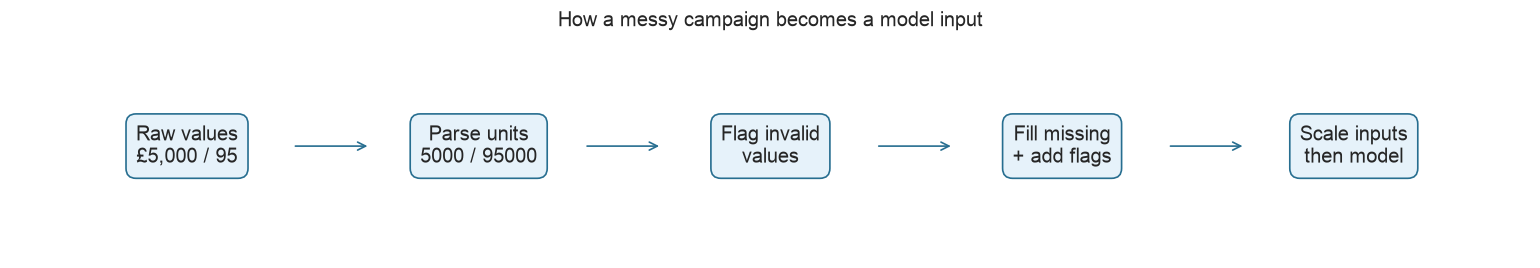

In [24]:
preprocessing_steps = ["Raw values\n£5,000 / 95", "Parse units\n5000 / 95000", "Flag invalid\nvalues", "Fill missing\n+ add flags", "Scale inputs\nthen model"]
draw_process_diagram(preprocessing_steps, "How a messy campaign becomes a model input")

### 3.4 Make the parsing decisions visible

The examples below show how the same measurement can appear in different formats. Notice that an unmarked decimal engagement value is not automatically multiplied by 100; without a source-unit contract, doing so could silently change the meaning.

In [25]:
examples = [("£5,000", "AdSpend (GBP)"), ("GBP 2.5k", "AdSpend (GBP)"),
            ("3.2%", "EngagementRate (%)"), ("0.032", "EngagementRate (%)"),
            ("120k", "Followers"), ("0.5k", "Followers"), ("12 cats", "Followers")]
parsing_examples = pd.DataFrame(examples, columns=["Raw value", "Feature"])
parsing_examples["Parsed number"] = [parse_value(value, feature) for value, feature in examples]
display(parsing_examples)

,Raw value,Feature,Parsed number
0,"£5,000",AdSpend (GBP),5000.000
1,GBP 2.5k,AdSpend (GBP),2500.000
2,3.2%,EngagementRate (%),3.200
3,0.032,EngagementRate (%),0.032
4,120k,Followers,120000.000
5,0.5k,Followers,500.000
6,12 cats,Followers,NaN


#### Count missing and newly invalid values

In [26]:
development_cleaner = CampaignCleaner().fit(development_campaigns)
cleaned_development_campaigns = development_cleaner.transform(development_campaigns)
display(pd.Series(development_cleaner.upper_, name="Development upper fence").to_frame())
cleaning_summary = pd.DataFrame({"raw_missing": development_campaigns[PREDICTOR_COLUMNS].isna().sum(),
                      "missing_after_rules": cleaned_development_campaigns.isna().sum()})
cleaning_summary["newly_flagged"] = cleaning_summary.missing_after_rules - cleaning_summary.raw_missing
display(cleaning_summary)
display(cleaned_development_campaigns.describe().T.round(2))

,Development upper fence
Followers,518223.500000
AdSpend (GBP),26341.854683


,raw_missing,missing_after_rules,newly_flagged
Followers,0,2,2
EngagementRate (%),97,98,1
AdSpend (GBP),101,103,2
ContentQuality,96,96,0


,count,mean,std,min,25%,50%,75%,max
Followers,5118.0,100189.93,29798.54,20000.0,80279.75,100046.50,120055.25,200000.00
EngagementRate (%),5022.0,2.78,1.30,0.5,1.66,2.81,3.89,5.00
AdSpend (GBP),5017.0,4985.32,1478.65,1000.0,3959.45,4996.49,5993.52,9823.06
ContentQuality,5024.0,5.51,2.61,1.0,3.25,5.50,7.82,10.00


#### Compare the raw formatting patterns

In [27]:
def format_profile(campaigns):
    follower_numbers = pd.to_numeric(campaigns.Followers, errors="coerce")
    return pd.Series({"Small bare followers": follower_numbers.between(0,1000,inclusive="neither").mean(),
       "Percent sign": campaigns["EngagementRate (%)"].astype(str).str.contains("%", regex=False).mean(),
       "Currency sign": campaigns["AdSpend (GBP)"].astype(str).str.contains("£", regex=False).mean(),
       "Followers > 1 million": (follower_numbers > 1e6).mean(),
       "Any missing core input": campaigns[PREDICTOR_COLUMNS].isna().any(axis=1).mean()})

#### Show why test inputs need the same cleaning rules

In [28]:
format_comparison = pd.DataFrame({"Development": format_profile(development_campaigns), "Unlabeled test": format_profile(test_campaigns)})
display((100*format_comparison).round(2).rename_axis("Percentage of rows"))

,Development,Unlabeled test
Percentage of rows,,
Small bare followers,2.42,10.00
Percent sign,2.70,10.00
Currency sign,2.36,10.00
Followers > 1 million,0.04,0.25
Any missing core input,5.68,7.90


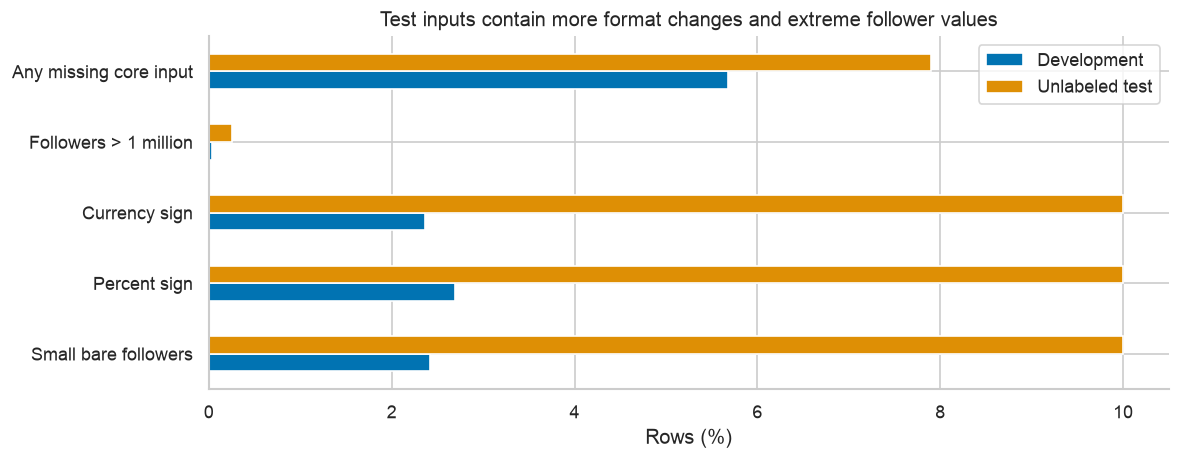

In [29]:
figure, axis = plt.subplots(figsize=(10,4))
(100*format_comparison).plot.barh(ax=axis)
axis.set(xlabel="Rows (%)", title="Test inputs contain more format changes and extreme follower values")
display_figure(figure)

#### Compare actual raw and cleaned rows

In [30]:
changed_rows = development_campaigns.index[cleaned_development_campaigns.isna().any(axis=1) |
    pd.to_numeric(development_campaigns.Followers, errors="coerce").between(0, 1000, inclusive="neither")][:8]
raw_examples = development_campaigns.loc[changed_rows, PREDICTOR_COLUMNS].add_prefix("Raw: ")
clean_examples = cleaned_development_campaigns.loc[changed_rows].add_prefix("Clean: ")
display(pd.concat([raw_examples, clean_examples], axis=1))
feature_demo = CampaignFeatures(engineered=True).fit(cleaned_development_campaigns)
display(feature_demo.medians_.to_frame("Development median used for imputation"))
display(feature_demo.transform(cleaned_development_campaigns).head().round(3))

,Raw: Followers,Raw: EngagementRate (%),Raw: AdSpend (GBP),Raw: ContentQuality,Clean: Followers,Clean: EngagementRate (%),Clean: AdSpend (GBP),Clean: ContentQuality
1340,72.0,1.943892702607864,NaN,6.645386,72000.0,1.943893,NaN,6.645386
4162,102733.0,2.510785645093836,5829.0796169748,NaN,102733.0,2.510786,5829.079617,NaN
6239,66.0,0.5292028462414875,2934.4397158444117,1.390582,66000.0,0.529203,2934.439716,1.390582
5225,113252.0,NaN,6644.8208994293345,1.815607,113252.0,NaN,6644.820899,1.815607
2433,57313.0,1.3680218465661982,5633.726932901408,NaN,57313.0,1.368022,5633.726933,NaN
5613,83422.0,4.77109468812499,NaN,4.739397,83422.0,4.771095,NaN,4.739397
7635,85.0,0.604158129621787,NaN,3.500515,85000.0,0.604158,NaN,3.500515
3080,149911.0,2.130847888159858,NaN,4.290740,149911.0,2.130848,NaN,4.290740


,Development median used for imputation
Followers,100046.500000
EngagementRate (%),2.806367
AdSpend (GBP),4996.493153
ContentQuality,5.501891


,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,log1p_Followers,log1p_EngagementRate (%),log1p_AdSpend (GBP),EngagedAudience,Spend_x_Quality,Engagement_x_Quality,Spend_per_Follower,Followers__missing,EngagementRate (%)__missing,AdSpend (GBP)__missing,ContentQuality__missing
978,132104.0,2.910,8588.448,6.168,11.791,1.364,9.058,3844.679,52970.755,17.950,0.065,0.0,0.0,0.0,0.0
6139,170134.0,1.905,5268.692,3.883,12.044,1.066,8.570,3240.754,20460.450,7.397,0.031,0.0,0.0,0.0,0.0
2532,111976.0,4.757,2100.899,5.546,11.626,1.750,7.651,5326.709,11651.794,26.383,0.019,0.0,0.0,0.0,0.0
4948,77975.0,4.166,5648.665,6.807,11.264,1.642,8.639,3248.562,38450.859,28.359,0.072,0.0,0.0,0.0,0.0
2227,78699.0,4.848,8076.411,8.719,11.273,1.766,8.997,3815.641,70419.896,42.274,0.103,0.0,0.0,0.0,0.0


#### Picture the missing cells

Each small square is one input value. White means observed; orange means missing. Rows are a reproducible sample, not the entire dataset. Missingness is an input-quality issue, not a target value of zero.

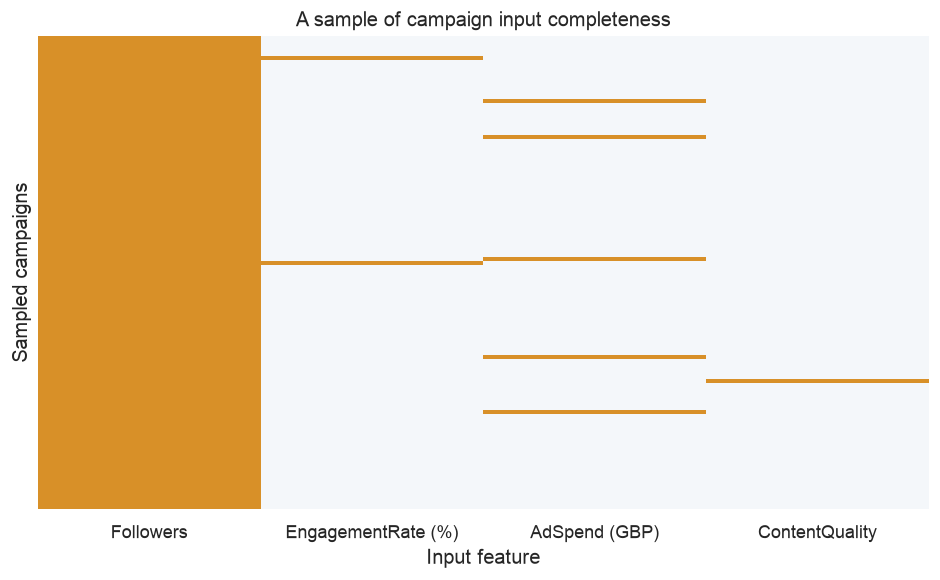

In [31]:
missingness_sample = training_campaigns[PREDICTOR_COLUMNS].sample(120, random_state=RANDOM_SEED).isna()
figure, axis = plt.subplots(figsize=(8, 5))
sns.heatmap(missingness_sample, cmap=["#F4F7FA", "#D89028"], cbar=False, yticklabels=False, ax=axis)
axis.set(title="A sample of campaign input completeness", ylabel="Sampled campaigns", xlabel="Input feature")
display_figure(figure)

### Cleaning observations

The upper fences and newly flagged counts above make every removal inspectable. Flagged **cells**, not entire campaigns, are removed from the feature representation. More training data is retained, and imputation uncertainty can be audited later. The raw files remain intact.

The test file contains 200 small follower values, 200 percentage strings and 200 currency strings across just 2,000 rows (10% each), compared with 200 of each across 8,000 training rows (2.5%). String normalization should therefore be invariant, and follower interpretation deserves its own experiment. Extreme corruption is also proportionally more common in the test file. Do not mistake this formatting shift for a change in sales behavior.

## 4. Exploratory analysis: development data only

The plots below separate distributions, relationships and temporal summaries. Correlation is descriptive; it cannot establish that changing spend or content causes additional sales. Histograms use valid, non-imputed values so the median replacement does not create artificial spikes.

In [32]:
exploration_data = cleaned_development_campaigns.assign(**{TARGET_COLUMN: development_sales})

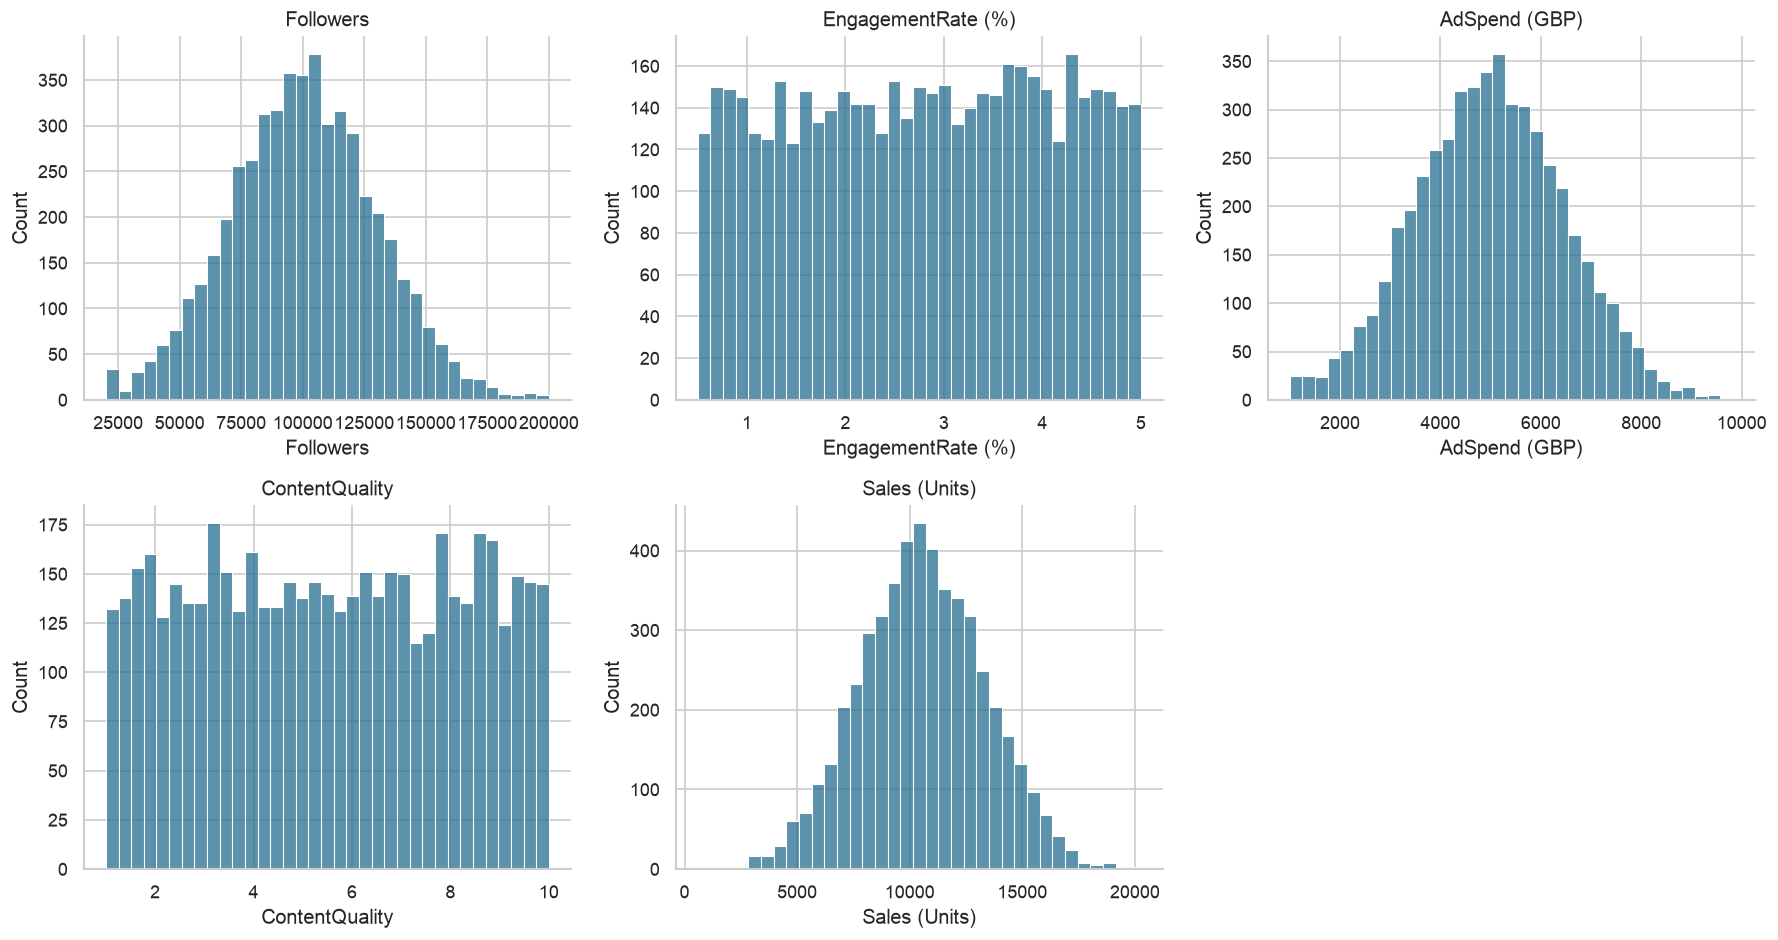

In [33]:
figure, axes = plt.subplots(2,3,figsize=(15,8))
for axis, column_name in zip(axes.flat, PREDICTOR_COLUMNS+[TARGET_COLUMN]):
    sns.histplot(exploration_data[column_name], bins=35, ax=axis, color="#276E90")
    axis.set_title(column_name)
axes.flat[-1].axis("off")
display_figure(figure)

### Distribution observations

The cleaned follower and spend distributions are concentrated around roughly 100,000 followers and £5,000 respectively. Engagement spans approximately 0.5–5 percentage points, and quality covers the stated 1–10 range. Sales have a broad, roughly bell-shaped distribution.

This matters for feature engineering: log transforms are worth testing, but the valid inputs are not so strongly skewed that logs must help. Large sales values alone are not grounds for deleting rows. Missing values are omitted from these histograms so imputation does not create an artificial median spike.

### Compare each predictor with sales

Each dot represents a development campaign. The orange line connects the median sales in ten equal-frequency input groups. It makes the broad relationship easier to see despite substantial campaign-to-campaign variation.

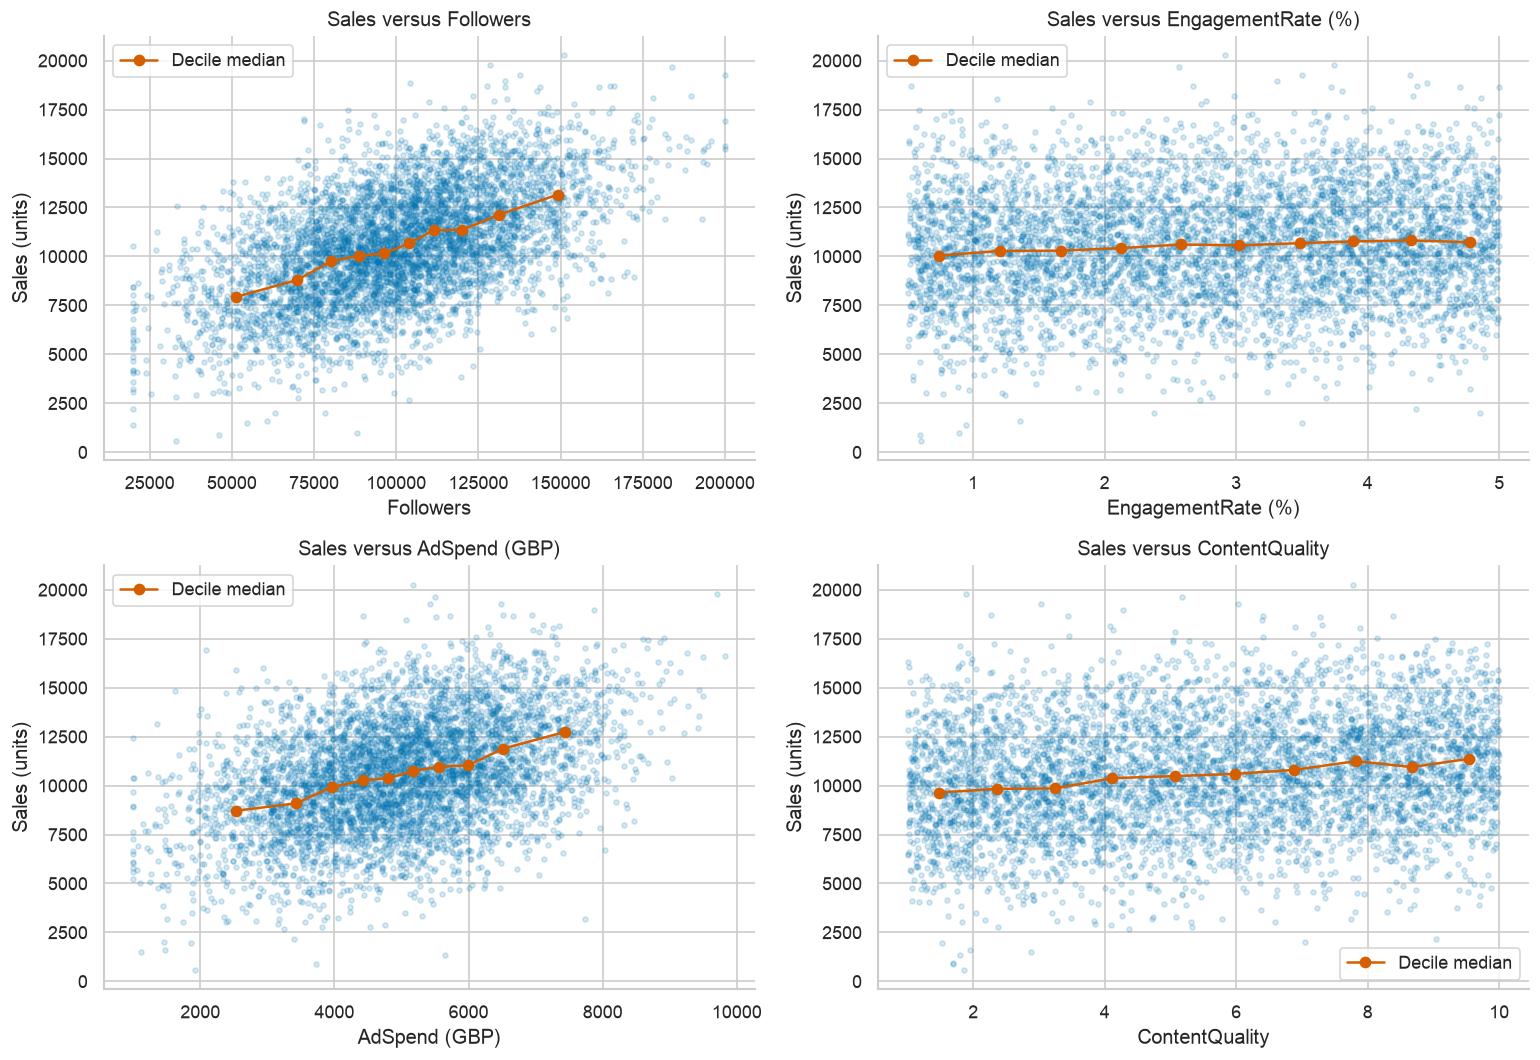

In [34]:
figure, axes = plt.subplots(2,2,figsize=(13,9))
for axis, column_name in zip(axes.flat, PREDICTOR_COLUMNS):
    axis.scatter(exploration_data[column_name], development_sales, s=9, alpha=.16)
    feature_groups = pd.qcut(exploration_data[column_name], 10, duplicates="drop")
    group_medians = exploration_data.groupby(feature_groups, observed=True).agg(x=(column_name,"median"), sales=(TARGET_COLUMN,"median"))
    axis.plot(group_medians.x, group_medians.sales, color="#D55E00", marker="o", label="Decile median")
    axis.set(xlabel=column_name, ylabel="Sales (units)", title=f"Sales versus {column_name}")
    axis.legend()
display_figure(figure)

### Relationship observations

- **Followers:** higher reach is associated with higher median sales. The trend is approximately increasing and close to linear over much of the observed range.
- **Spend:** higher campaign spending is also associated with higher median sales.
- **Quality:** a positive relationship is present, but the variation around it is large.
- **Engagement:** the marginal relationship is weaker than the relationships for reach and spend.

None of these scatterplots shows a nearly deterministic relationship. Campaigns with similar inputs can have very different sales. This warns against expecting near-perfect predictions from these four attributes alone.

### Correlation and time patterns

Spearman correlation measures whether larger values of one variable tend to accompany larger values of another. It detects monotonic relationships and is less sensitive to extreme magnitudes than ordinary linear correlation. Monthly averages help identify obvious time drift; the error bars describe uncertainty in monthly means, not prediction intervals for individual campaigns.

#### Rank the associations and inspect monthly averages

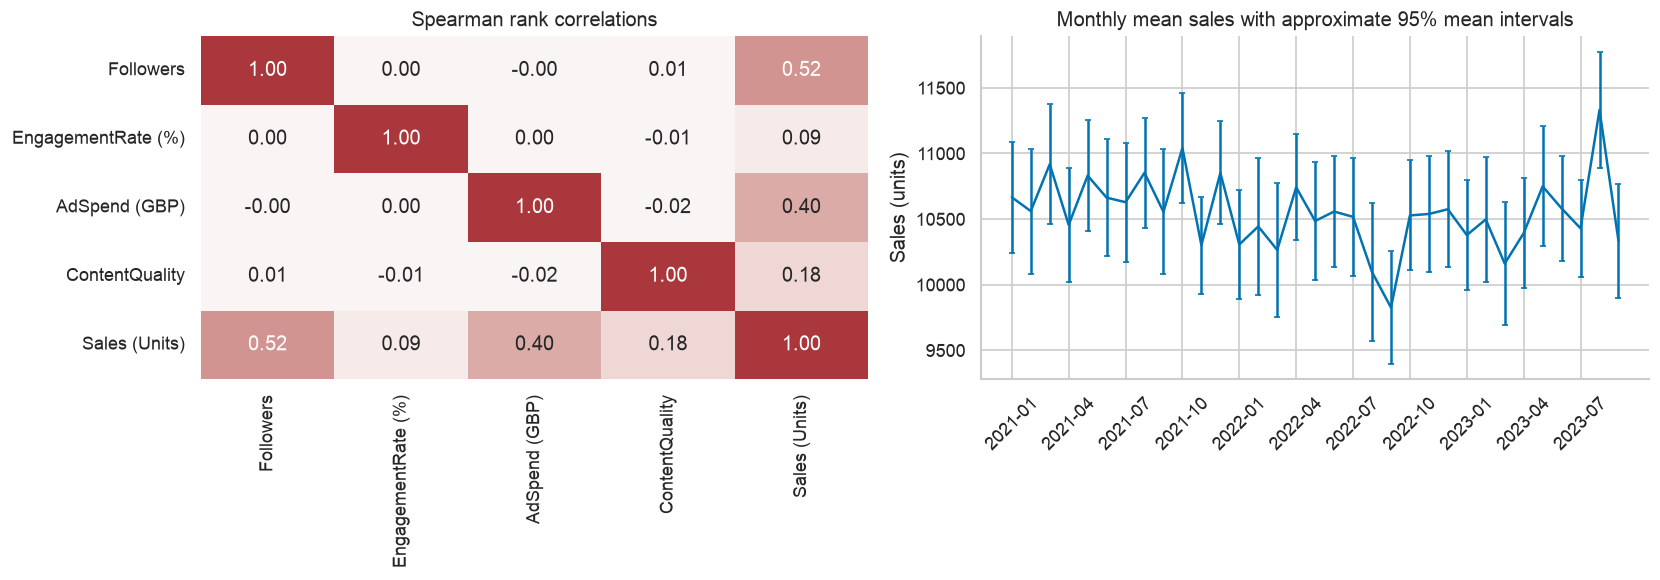

In [35]:
figure, axes = plt.subplots(1,2,figsize=(14,5))
sns.heatmap(exploration_data.corr(method="spearman"), annot=True, fmt=".2f", cmap="vlag", center=0, ax=axes[0], cbar=False)
axes[0].set_title("Spearman rank correlations")
monthly_sales_summary = pd.DataFrame({"month": pd.to_datetime(development_campaigns.Timestamp).dt.to_period("M").astype(str), "sales": development_sales})
monthly_sales_summary = monthly_sales_summary.groupby("month").sales.agg(["mean","count","std"])
axes[1].errorbar(np.arange(len(monthly_sales_summary)), monthly_sales_summary["mean"], yerr=1.96*monthly_sales_summary["std"]/np.sqrt(monthly_sales_summary["count"]), capsize=2)
axes[1].set_xticks(np.arange(0,len(monthly_sales_summary),3), monthly_sales_summary.index[::3], rotation=45)
axes[1].set(title="Monthly mean sales with approximate 95% mean intervals", ylabel="Sales (units)")
display_figure(figure)

#### Read the correlation values

In [36]:
sales_correlations = exploration_data.corr(method="spearman")[TARGET_COLUMN].drop(TARGET_COLUMN).sort_values(ascending=False)
display(development_sales.describe().to_frame("Development sales"))

,Development sales
count,5120.000000
mean,10554.912695
std,2800.290516
min,590.000000
25%,8647.500000
50%,10510.000000
75%,12468.000000
max,20263.000000


**Observed associations:** Followers: Spearman ρ = 0.520; AdSpend (GBP): Spearman ρ = 0.400; ContentQuality: Spearman ρ = 0.183; EngagementRate (%): Spearman ρ = 0.085. These are marginal relationships, not causal effects.

#### Compare low-sales and high-sales campaigns

In [37]:
low_sales_medians = exploration_data.loc[development_sales <= development_sales.quantile(.25), PREDICTOR_COLUMNS].median()
high_sales_medians = exploration_data.loc[development_sales >= development_sales.quantile(.75), PREDICTOR_COLUMNS].median()
sales_quartile_comparison = pd.DataFrame({"Bottom sales quartile median":low_sales_medians, "Top sales quartile median":high_sales_medians})
display(sales_quartile_comparison.round(2))

,Bottom sales quartile median,Top sales quartile median
Followers,78892.00,119186.50
EngagementRate (%),2.65,3.04
AdSpend (GBP),4225.15,5799.42
ContentQuality,4.44,6.32


#### Look at spend and quality together

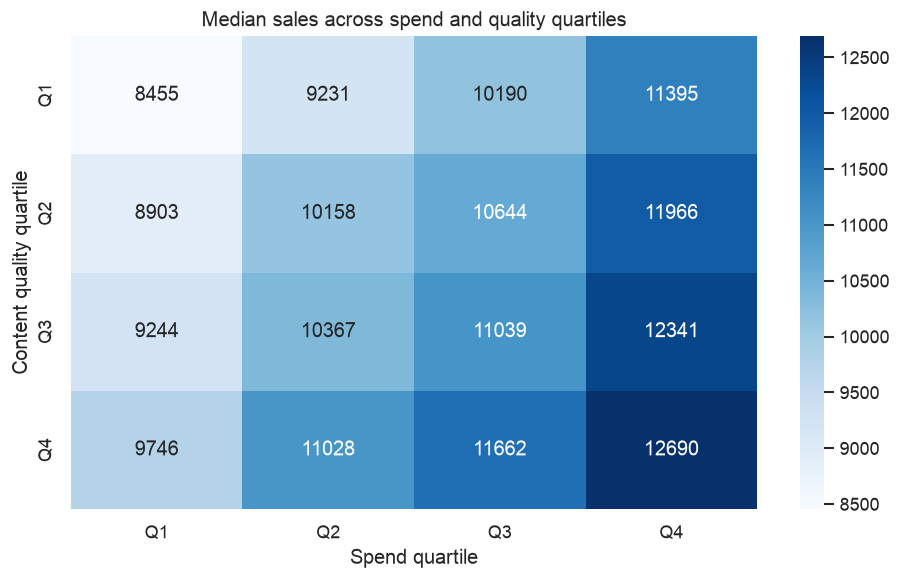

In [38]:
figure, axis = plt.subplots(figsize=(8,5))
spend_quality_groups = exploration_data.assign(spend_bin=pd.qcut(exploration_data["AdSpend (GBP)"],4,labels=["Q1","Q2","Q3","Q4"]),
                  quality_bin=pd.qcut(exploration_data.ContentQuality,4,labels=["Q1","Q2","Q3","Q4"]))
sns.heatmap(spend_quality_groups.pivot_table(index="quality_bin",columns="spend_bin",values=TARGET_COLUMN,aggfunc="median",observed=True),annot=True,fmt=".0f",cmap="Blues",ax=axis)
axis.set(title="Median sales across spend and quality quartiles", xlabel="Spend quartile", ylabel="Content quality quartile")
display_figure(figure)

**Interpretation:** high-versus-low outcome profiles identify candidate predictors, but selecting campaigns by their realized sales cannot tell us which intervention would improve sales. The spend–quality table motivates an interaction candidate; CV decides whether it adds predictive value.

## 5. Model experiments and cross-validation

### 5.1 Resolve the follower-scale ambiguity

Use the same Ridge regressor and identical five folds for all three parsing policies. This isolates the effect of the rule. We select the policy with the lowest development CV RMSE, then freeze it for every subsequent candidate. Although this consumes development information, it never uses holdout labels. For a new data source the mode must be reconsidered; legitimate micro-influencers could otherwise be multiplied incorrectly.

#### Build the reusable modeling pipeline

In [39]:
def build_model_pipeline(model, engineered=False, mode="scale", shape=None):
    steps = [("clean",CampaignCleaner(follower_mode=mode)),
             ("features",CampaignFeatures(engineered=engineered))]
    if shape is not None:
        steps.append(("shape",shape))
    steps += [("scale",StandardScaler()),("model",model)]
    return Pipeline(steps)

#### Run the three follower-unit experiments

In [40]:
evaluation_metrics = {"rmse":"neg_root_mean_squared_error", "mae":"neg_mean_absolute_error", "r2":"r2"}
follower_policy_results=[]
for mode in ["keep","missing","scale"]:
    result = cross_validate(build_model_pipeline(Ridge(alpha=10),mode=mode),development_campaigns,development_sales,cv=development_folds,scoring=evaluation_metrics,n_jobs=1)
    follower_policy_results.append({"policy":mode,"CV RMSE":-result["test_rmse"].mean(),"fold SD":result["test_rmse"].std(ddof=1)})
follower_policy_results=pd.DataFrame(follower_policy_results).sort_values("CV RMSE")
display(follower_policy_results.round(2))
selected_follower_policy=follower_policy_results.iloc[0].policy
print("Frozen follower policy:",selected_follower_policy)

,policy,CV RMSE,fold SD
2,scale,1981.96,79.76
1,missing,1996.78,78.95
0,keep,2080.89,78.20


Frozen follower policy: scale


#### Visualize five-fold cross-validation

Blue blocks train the model. The orange block evaluates it. The orange block moves so every group is evaluated once. The real folds contain shuffled rows; this diagram shows the roles, not consecutive dates.

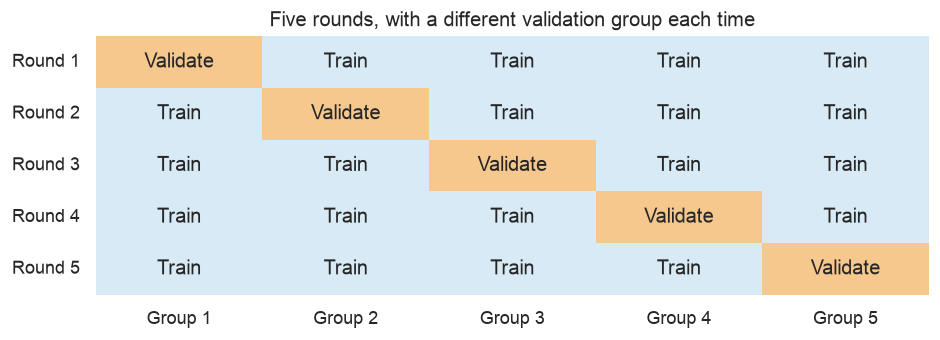

In [41]:
fold_roles = np.eye(5)
figure, axis = plt.subplots(figsize=(8, 3))
role_labels = np.where(fold_roles == 1, "Validate", "Train")
sns.heatmap(fold_roles, annot=role_labels, fmt="", cmap=["#D7EAF5", "#F7C88E"], cbar=False,
            xticklabels=[f"Group {number}" for number in range(1, 6)],
            yticklabels=[f"Round {number}" for number in range(1, 6)], ax=axis)
axis.set(title="Five rounds, with a different validation group each time")
display_figure(figure)

### What did the follower-policy experiment tell us?

Keeping small follower values literally gave CV RMSE around **2,081 units**. Marking them missing improved it to about **1,997**; converting them from thousands improved it further to about **1,982**.

This supports the scale-repair rule for this dataset, especially because the problem statement explicitly mentions mixed follower units. It does not prove that every future small count is in thousands. A genuine 95-follower creator would be misinterpreted without source metadata.

**Pipeline order:** raw rows → parse and clean → impute and create features → optional nonlinear expansion → standardize → fit the regressor. During CV, every learned step is fitted again on the training fold. The validation fold only passes through the fitted transformations.

### 5.2 Compare different model families

The mean predictor establishes whether the features help at all. Ridge tests an additive relationship with regularization. Engineered Ridge and quadratic Ridge test transformations and interactions; splines allow smooth nonlinear marginal responses. Huber downweights large residuals during fitting. Random Forest and Extra Trees model flexible interactions through bagging; histogram gradient boosting improves residual predictions sequentially. A log-target Ridge candidate tests relative rather than absolute errors, but is still judged in **original sales units**; inverse-log predictions can underestimate the conditional mean, so there is no assumption this will help RMSE.

All candidates have identical folds and cleaning. Fold standard deviations describe variability, not confidence intervals. Model selection CV is optimistic after searching multiple candidates; the untouched holdout is the final check.

### What is each experiment testing?

| Approach | Question being tested | Main tradeoff |
|---|---|---|
| Mean baseline | Can inputs improve on one constant forecast? | Simple benchmark with no campaign-specific information |
| Ridge, original inputs | Is a regularized additive relationship enough? | Easy to interpret, but limited nonlinear flexibility |
| Ridge, engineered inputs | Do logs and marketing interactions add signal? | More hypotheses can also introduce noise |
| Quadratic Ridge | Do squared terms and pairwise interactions help? | More flexibility and more opportunities to overfit |
| Spline Ridge | Are individual input effects smoothly nonlinear? | Flexible marginal effects without arbitrary tree partitions |
| Huber regression | Does reducing the influence of large residuals help? | Robust fitting may help noisy cases, but RMSE still counts every error |
| Random Forest | Can averaged decision trees capture useful interactions? | Can overfit small groups and extrapolates poorly |
| Extra Trees | Does greater split randomness improve tree generalization? | Trades some bias for lower ensemble variance |
| Histogram boosting | Can sequential residual correction reveal structure? | Needs complexity control to avoid fitting noise |
| Log-target Ridge | Is modeling proportional sales variation more suitable? | Does not directly minimize original-unit squared error |

**Reading the output:** compare CV RMSE first, then MAE, R² and fold variability. A very low training RMSE with a much worse validation RMSE suggests overfitting. A tiny difference between two CV means is not strong evidence that one approach is genuinely superior.

In [42]:
candidate_pipelines = {}

#### Start with a constant benchmark

In [43]:
candidate_pipelines['Mean baseline'] = build_model_pipeline(DummyRegressor(strategy='mean'), mode=selected_follower_policy)

#### Try regularized linear regression

In [44]:
candidate_pipelines['Ridge raw'] = build_model_pipeline(Ridge(alpha=10), mode=selected_follower_policy)

#### Add the proposed marketing features

In [45]:
candidate_pipelines['Ridge engineered'] = build_model_pipeline(Ridge(alpha=10), True, selected_follower_policy)

#### Allow quadratic terms

In [46]:
candidate_pipelines['Quadratic Ridge'] = build_model_pipeline(Ridge(alpha=100), mode=selected_follower_policy, shape=PolynomialFeatures(degree=2, include_bias=False))

#### Allow smooth nonlinear curves

In [47]:
candidate_pipelines['Spline Ridge'] = build_model_pipeline(Ridge(alpha=10), mode=selected_follower_policy, shape=SplineTransformer(n_knots=4, degree=3))

#### Try robust regression

In [48]:
candidate_pipelines['Huber'] = build_model_pipeline(HuberRegressor(epsilon=1.35, max_iter=2000), mode=selected_follower_policy)

#### Average many decision trees

In [49]:
candidate_pipelines['Random Forest'] = build_model_pipeline(RandomForestRegressor(n_estimators=160, min_samples_leaf=5, n_jobs=2, random_state=RANDOM_SEED), mode=selected_follower_policy)

#### Increase tree-split randomness

In [50]:
candidate_pipelines['Extra Trees'] = build_model_pipeline(ExtraTreesRegressor(n_estimators=200, min_samples_leaf=3, n_jobs=2, random_state=RANDOM_SEED), mode=selected_follower_policy)

#### Fit a boosting model

In [51]:
candidate_pipelines['Histogram boosting'] = build_model_pipeline(HistGradientBoostingRegressor(max_iter=250, max_leaf_nodes=15, l2_regularization=10, random_state=RANDOM_SEED), mode=selected_follower_policy)

#### Try predicting log sales

In [52]:
candidate_pipelines['Log-target Ridge'] = build_model_pipeline(TransformedTargetRegressor(regressor=Ridge(alpha=10), func=np.log1p, inverse_func=np.expm1), True, selected_follower_policy)

#### Collect the same measurements for every candidate

We keep the mean error, variation across folds and training error so that comparisons remain consistent.

In [53]:
def summarize_validation(model_name, validation, elapsed_seconds):
    return {"model": model_name,
            "CV RMSE": -validation["test_rmse"].mean(),
            "fold SD": validation["test_rmse"].std(ddof=1),
            "CV MAE": -validation["test_mae"].mean(),
            "CV R2": validation["test_r2"].mean(),
            "Train RMSE": -validation["train_rmse"].mean(),
            "seconds": elapsed_seconds}

#### Run the comparison

Each candidate sees exactly the same development folds. The loop repeats the same fair experiment for each model.

In [54]:
candidate_results = []
for model_name, candidate_model in candidate_pipelines.items():
    start_time = time.perf_counter()
    validation = cross_validate(candidate_model, development_campaigns, development_sales, cv=development_folds,
        scoring=evaluation_metrics, return_train_score=True, n_jobs=1)
    elapsed_seconds = time.perf_counter() - start_time
    candidate_results.append(summarize_validation(model_name, validation, elapsed_seconds))

#### Rank the candidates by validation RMSE

In [55]:
model_comparison=pd.DataFrame(candidate_results).set_index("model").sort_values("CV RMSE")
display(model_comparison.round(3))

,CV RMSE,fold SD,CV MAE,CV R2,Train RMSE,seconds
model,,,,,,
Huber,1981.958,79.963,1573.252,0.498,1978.451,0.352
Ridge raw,1981.961,79.760,1573.114,0.498,1978.369,0.341
Ridge engineered,1984.103,79.190,1575.058,0.497,1977.529,0.353
Spline Ridge,1984.824,77.211,1574.875,0.497,1974.565,0.360
Quadratic Ridge,1990.277,79.070,1579.992,0.494,1975.939,0.347
Log-target Ridge,2003.577,78.074,1591.143,0.487,1996.954,0.386
Extra Trees,2041.915,75.430,1625.038,0.467,1296.195,1.680
Random Forest,2053.388,72.734,1631.711,0.461,1422.291,2.218
Histogram boosting,2064.335,74.672,1639.132,0.455,1628.027,0.982


#### Compare the validation errors visually

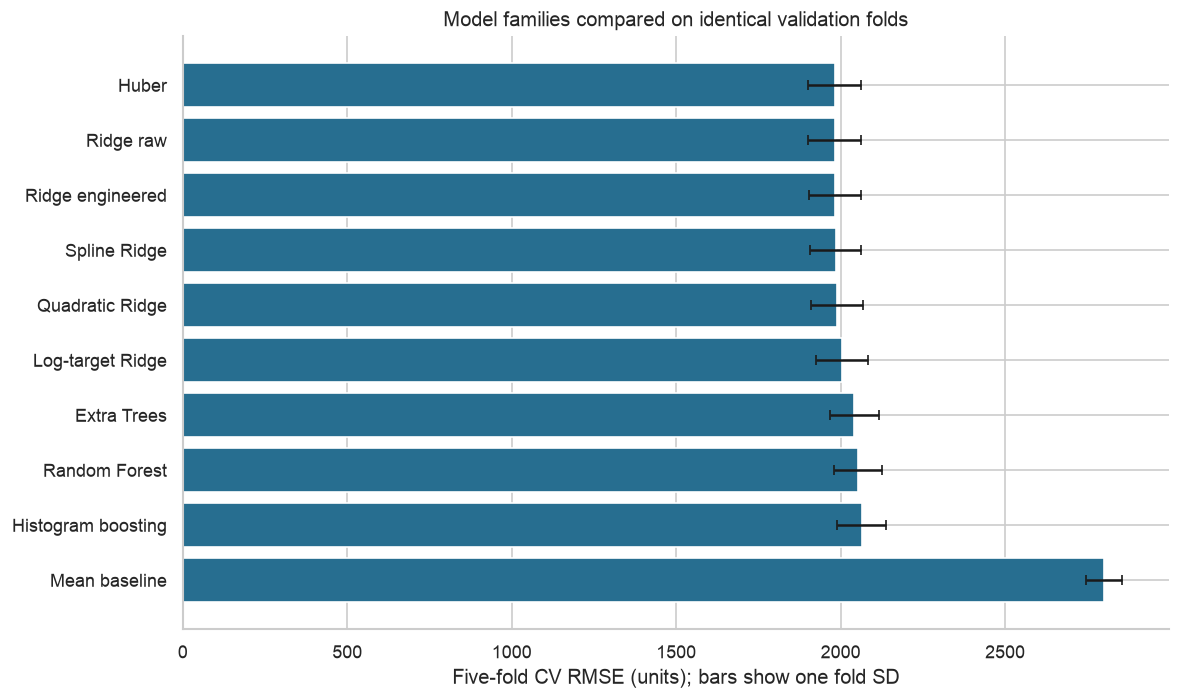

In [56]:
figure,axis=plt.subplots(figsize=(10,6))
ranked_models=model_comparison.sort_values("CV RMSE",ascending=False)
axis.barh(ranked_models.index,ranked_models["CV RMSE"],xerr=ranked_models["fold SD"],color="#276E90",capsize=3)
axis.set(xlabel="Five-fold CV RMSE (units); bars show one fold SD",title="Model families compared on identical validation folds")
display_figure(figure)

#### Read the leading result

**Observation:** Huber leads the initial comparison with CV RMSE 1,982.0. Train–validation differences above reveal how much each family overfits. Complexity alone is not evidence of improvement.

#### Visual lesson: fitting better is not always predicting better

Compare the two bars for each model. Tree ensembles fit the training rows more closely, but their validation errors are higher. The goal is the lower **validation** error.

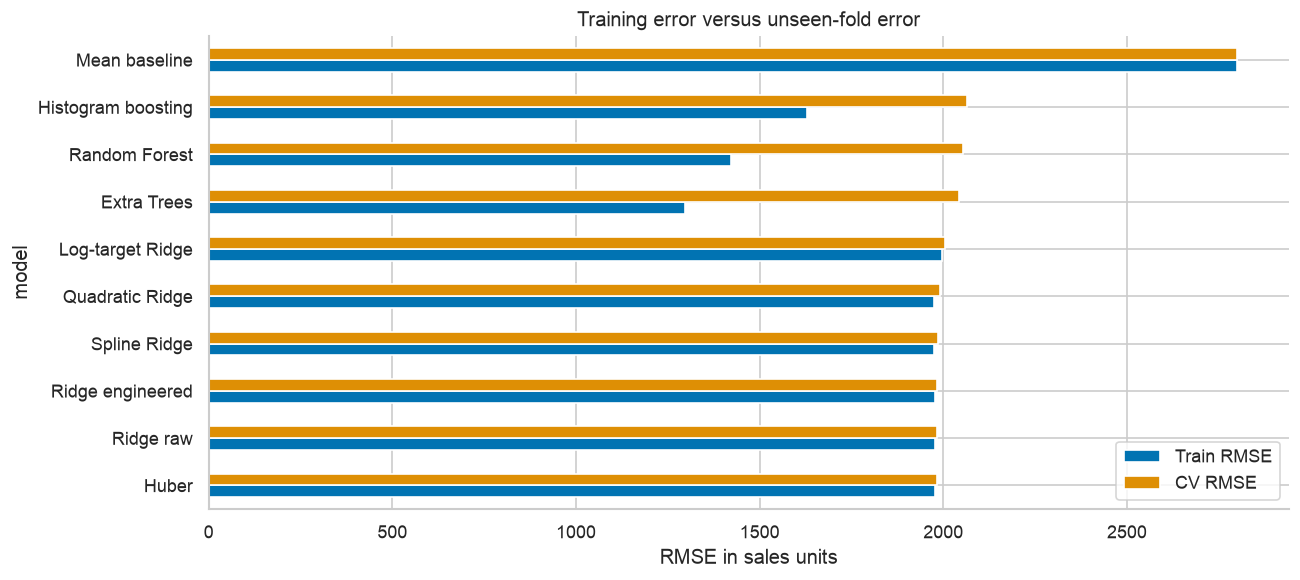

In [57]:
figure, axis = plt.subplots(figsize=(11, 5))
model_comparison[["Train RMSE", "CV RMSE"]].plot.barh(ax=axis)
axis.set(title="Training error versus unseen-fold error", xlabel="RMSE in sales units")
display_figure(figure)

### Model-comparison observations

Huber and raw-feature Ridge both achieve about **1,982 CV RMSE**. Their initial difference is much less than one unit, against roughly **80 units of variation across folds**. They should be regarded as practically tied.

Adding engineered features, quadratic terms or splines does not improve the validation score. The tree ensembles obtain lower training error but worse validation error, which indicates that their additional flexibility is fitting patterns that do not transfer as well to unseen campaigns.

The useful conclusion is that an approximately additive model is competitive for the supplied features. This does **not** prove the real sales process is linear or that the remaining error is irreducible noise. Relevant predictors may be missing.

### 5.3 Tune promising families and test a fixed blend

Tune the two best non-baseline families from the initial comparison using compact, explicit grids. This concentrates computation on promising approaches. We also evaluate a **fixed equal-weight average** of the two tuned pipelines. The blend is assessed by out-of-fold predictions; weights are not optimized on the holdout. Because hyperparameters were already selected on these folds, blend and tuned CV scores are model-selection estimates, not nested-CV generalization claims.

Final selection uses minimum mean CV RMSE across original, tuned and blended candidates. We preserve every initial candidate so tuning cannot force a worse model to win.

### What do the tuned settings mean?

- **Ridge `alpha`:** the strength of coefficient shrinkage. Larger values discourage large weights; too much shrinkage can miss real effects.
- **Huber `epsilon`:** controls when a residual is treated as large and receives less influence in fitting. Smaller values make the fit more resistant to large residuals.
- **Huber `alpha`:** adds coefficient regularization to the robust loss.

`GridSearchCV` fits every listed combination on the same five development folds. Negative RMSE is used internally because scikit-learn maximizes scores; we reverse its sign when reporting the error.

The equal-weight blend averages the two tuned predictions. Blending can help when models make different mistakes. When two additive models make nearly identical predictions, there is little diversity to exploit.

In [58]:
parameter_grids = {}

#### Candidate settings for Ridge raw, Ridge engineered, Quadratic Ridge

In [59]:
parameter_grids['Ridge raw'] = {'model__alpha': [0.01, 1, 10, 100, 1000]}
parameter_grids['Ridge engineered'] = {'model__alpha': [0.1, 1, 10, 100, 1000]}
parameter_grids['Quadratic Ridge'] = {'model__alpha': [1, 10, 100, 1000, 10000]}

#### Candidate settings for Spline Ridge, Huber, Random Forest

In [60]:
parameter_grids['Spline Ridge'] = {'shape__n_knots': [3, 4, 6], 'model__alpha': [1, 10, 100]}
parameter_grids['Huber'] = {'model__epsilon': [1.2, 1.35, 1.8], 'model__alpha': [0.0001, 0.1]}
parameter_grids['Random Forest'] = {'model__min_samples_leaf': [2, 5, 10], 'model__max_features': [0.7, 1.0]}

#### Candidate settings for Extra Trees, Histogram boosting, Log-target Ridge

In [61]:
parameter_grids['Extra Trees'] = {'model__min_samples_leaf': [1, 3, 8], 'model__max_features': [0.7, 1.0]}
parameter_grids['Histogram boosting'] = {'model__max_leaf_nodes': [7, 15, 31], 'model__l2_regularization': [1, 10, 100]}
parameter_grids['Log-target Ridge'] = {'model__regressor__alpha': [0.1, 1, 10, 100, 1000]}

#### Select the two strongest model families using development results

In [62]:
promising_model_names = model_comparison.drop(index="Mean baseline").head(2).index
model_candidates = dict(candidate_pipelines)
selection_results = model_comparison[["CV RMSE", "fold SD"]].copy()
parameter_searches = {}

#### Fit the parameter searches

For each setting, the search trains on four folds and validates on the fifth. No holdout labels enter this step.

In [63]:
for model_name in promising_model_names:
    parameter_search = GridSearchCV(candidate_pipelines[model_name], parameter_grids[model_name],
        cv=development_folds, scoring="neg_root_mean_squared_error", n_jobs=1, refit=True)
    parameter_search.fit(development_campaigns, development_sales)
    parameter_searches[model_name] = parameter_search
    print(model_name, parameter_search.best_params_, "RMSE:", -parameter_search.best_score_)

Huber {'model__alpha': 0.0001, 'model__epsilon': 1.2} RMSE: 1981.8268554560982


Ridge raw {'model__alpha': 10} RMSE: 1981.9605317978014


#### Retain the full tuning table

A higher negative score means a smaller error. The table keeps every tried combination, including unsuccessful ones.

In [64]:
tuning_result_tables = []
for model_name, parameter_search in parameter_searches.items():
    parameter_results = pd.DataFrame(parameter_search.cv_results_)
    parameter_results["family"] = model_name
    columns_to_show = ["family", "params", "mean_test_score", "std_test_score", "rank_test_score"]
    tuning_result_tables.append(parameter_results[columns_to_show])
hyperparameter_results = pd.concat(tuning_result_tables, ignore_index=True)
display(hyperparameter_results.sort_values("mean_test_score", ascending=False).head(12))

,family,params,mean_test_score,std_test_score,rank_test_score
0,Huber,"{'model__alpha': 0.0001, 'model__epsilon': 1.2}",-1981.826855,71.215661,1
1,Huber,"{'model__alpha': 0.0001, 'model__epsilon': 1.35}",-1981.958214,71.521377,2
8,Ridge raw,{'model__alpha': 10},-1981.960532,71.339613,1
7,Ridge raw,{'model__alpha': 1},-1981.965026,71.322491,2
6,Ridge raw,{'model__alpha': 0.01},-1981.966103,71.320562,3
2,Huber,"{'model__alpha': 0.0001, 'model__epsilon': 1.8}",-1982.016412,71.512125,3
9,Ridge raw,{'model__alpha': 100},-1982.416291,71.471816,4
4,Huber,"{'model__alpha': 0.1, 'model__epsilon': 1.35}",-1983.694403,71.843248,4
3,Huber,"{'model__alpha': 0.1, 'model__epsilon': 1.2}",-1983.696985,71.512284,5
5,Huber,"{'model__alpha': 0.1, 'model__epsilon': 1.8}",-1983.762198,71.724455,6


#### Add the tuned candidates without discarding the original models

In [65]:
tuned_model_names = []
for model_name, parameter_search in parameter_searches.items():
    tuned_model_name = model_name + " tuned"
    tuned_model_names.append(tuned_model_name)
    model_candidates[tuned_model_name] = parameter_search.best_estimator_
    best_row = pd.DataFrame(parameter_search.cv_results_).iloc[parameter_search.best_index_]
    fold_rmse = np.array([-best_row[f"split{fold_number}_test_score"] for fold_number in range(5)])
    selection_results.loc[tuned_model_name] = [fold_rmse.mean(), fold_rmse.std(ddof=1)]

#### Average the two tuned predictions and evaluate the blend

In [66]:
blended_model=VotingRegressor([(f"model{i}",clone(model_candidates[name])) for i,name in enumerate(tuned_model_names)])
blend_validation=cross_validate(blended_model,development_campaigns,development_sales,cv=development_folds,scoring="neg_root_mean_squared_error",n_jobs=1)
model_candidates["Equal-weight blend"]=blended_model
selection_results.loc["Equal-weight blend"]=[-blend_validation["test_score"].mean(),blend_validation["test_score"].std(ddof=1)]
selection_results=selection_results.sort_values("CV RMSE")
selected_model_name=selection_results.index[0]
selected_model_specification=clone(model_candidates[selected_model_name])
display(selection_results.round(2))
print("Frozen final choice:",selected_model_name)

,CV RMSE,fold SD
model,,
Huber tuned,1981.83,79.62
Equal-weight blend,1981.86,79.69
Huber,1981.96,79.96
Ridge raw,1981.96,79.76
Ridge raw tuned,1981.96,79.76
Ridge engineered,1984.10,79.19
Spline Ridge,1984.82,77.21
Quadratic Ridge,1990.28,79.07
Log-target Ridge,2003.58,78.07


Frozen final choice: Huber tuned


#### Freeze the model with the smallest development CV error

In [67]:
out_of_fold_predictions=cross_val_predict(selected_model_specification,development_campaigns,development_sales,cv=development_folds,n_jobs=1)
out_of_fold_predictions=np.maximum(out_of_fold_predictions,0)
print("Pooled development OOF metrics:",calculate_regression_scores(development_sales,out_of_fold_predictions))

Pooled development OOF metrics: {'RMSE': 1983.1059869139863, 'MAE': 1573.3307045204365, 'R2': 0.4983850129434194}


### Tuning decision

The selected Huber settings are `epsilon=1.2` and `alpha=0.0001`. Tuning reduces mean CV RMSE by only about **0.13 units** compared with the initial Huber candidate. The equal-weight blend is similarly close.

The experiment therefore finds **no meaningful practical separation** between the leading additive approaches. We retain the lowest-CV-RMSE specification according to the stated rule, but do not present its tiny lead as a major improvement. All later evaluations keep this specification fixed.

## 6. Final evaluation and calibrated uncertainty

The selected pipeline is now frozen. Fit it on development data; use the disjoint calibration subset only to estimate a 90% split-conformal interval. Its half-width is the finite-sample corrected 90th percentile of absolute calibration residuals. Such intervals have marginal coverage under exchangeability; they are not guaranteed for every campaign, shifted populations or a model refitted on additional data.

Evaluate the frozen development-fitted model once on the untouched holdout, alongside a development-mean baseline. Predictions are constrained to nonnegative units. Keep decimal forecasts because they estimate expected units; rounding is not needed for RMSE. Bootstrap uncertainty below resamples holdout campaigns and describes this fitted model's score uncertainty, not the entire model-selection process.

#### Fit the frozen model and calculate calibration errors

In [68]:
evaluation_model=clone(selected_model_specification).fit(development_campaigns,development_sales)
calibration_predictions=np.maximum(evaluation_model.predict(calibration_campaigns),0)
miscoverage_rate=.10
calibration_errors=np.abs(calibration_sales.to_numpy()-calibration_predictions)
calibration_quantile=min(1,np.ceil((len(calibration_errors)+1)*(1-miscoverage_rate))/len(calibration_errors))
interval_half_width=float(np.quantile(calibration_errors,calibration_quantile,method="higher"))
holdout_predictions=np.maximum(evaluation_model.predict(holdout_campaigns),0)
holdout_scores=calculate_regression_scores(holdout_sales,holdout_predictions)
baseline_scores=calculate_regression_scores(holdout_sales,np.repeat(development_sales.mean(),len(holdout_sales)))

#### Measure performance on the untouched holdout

In [69]:
holdout_comparison=pd.DataFrame([baseline_scores,holdout_scores],index=["Development mean baseline",selected_model_name])
display(holdout_comparison.round(3))
interval_lower_bounds=np.maximum(0,holdout_predictions-interval_half_width)
interval_upper_bounds=holdout_predictions+interval_half_width
holdout_interval_coverage=float(np.mean((holdout_sales>=interval_lower_bounds)&(holdout_sales<=interval_upper_bounds)))
random_generator=np.random.default_rng(RANDOM_SEED)
bootstrap_scores=[]

,RMSE,MAE,R2
Development mean baseline,2819.968,2249.555,-0.001
Huber tuned,2156.556,1691.690,0.415


#### Calculate interval coverage and bootstrap score uncertainty

In [70]:
for _ in range(1000):
    sample_indices=random_generator.integers(0,len(holdout_sales),len(holdout_sales))
    bootstrap_scores.append(calculate_regression_scores(holdout_sales.to_numpy()[sample_indices],holdout_predictions[sample_indices]))
bootstrap_intervals=pd.DataFrame(bootstrap_scores).quantile([.025,.975]).T
bootstrap_intervals.columns=["2.5%","97.5%"]
display(bootstrap_intervals.round(3))
print(f"90% interval half-width: {interval_half_width:,.1f} units; holdout coverage: {holdout_interval_coverage:.1%}; mean width: {np.mean(interval_upper_bounds-interval_lower_bounds):,.1f} units")

,2.5%,97.5%
RMSE,2075.471,2236.617
MAE,1626.101,1755.055
R2,0.370,0.456


90% interval half-width: 3,331.2 units; holdout coverage: 88.4%; mean width: 6,662.4 units


**Final holdout observation:** RMSE **2,156.6 units**, MAE **1,691.7 units**, R² **0.415**. RMSE improves by **23.5%** over the mean baseline. These estimates apply to the reserved historical campaigns, not to the unlabeled test file.

#### Work through one prediction error by hand

This small table uses the first five real holdout predictions. Absolute error ignores direction; squared error gives more weight to big misses. Averaging over **all** holdout rows produces the reported MAE and RMSE.

In [71]:
error_examples = pd.DataFrame({"Actual sales": holdout_sales.to_numpy()[:5], "Predicted sales": holdout_predictions[:5]})
error_examples["Actual minus predicted"] = error_examples["Actual sales"] - error_examples["Predicted sales"]
error_examples["Absolute error"] = error_examples["Actual minus predicted"].abs()
error_examples["Squared error"] = error_examples["Actual minus predicted"] ** 2
display(error_examples.round(1))

,Actual sales,Predicted sales,Actual minus predicted,Absolute error,Squared error
0,12895,12866.7,28.3,28.3,802.5
1,16217,13648.0,2569.0,2569.0,6599728.4
2,15489,14595.6,893.4,893.4,798174.8
3,16238,12044.6,4193.4,4193.4,17584444.7
4,10930,10933.6,-3.6,3.6,13.0


#### See the gap between actual and predicted sales

The vertical distance between each pair is its absolute error. A model can be close on some campaigns and far away on others; one average score hides that variation.

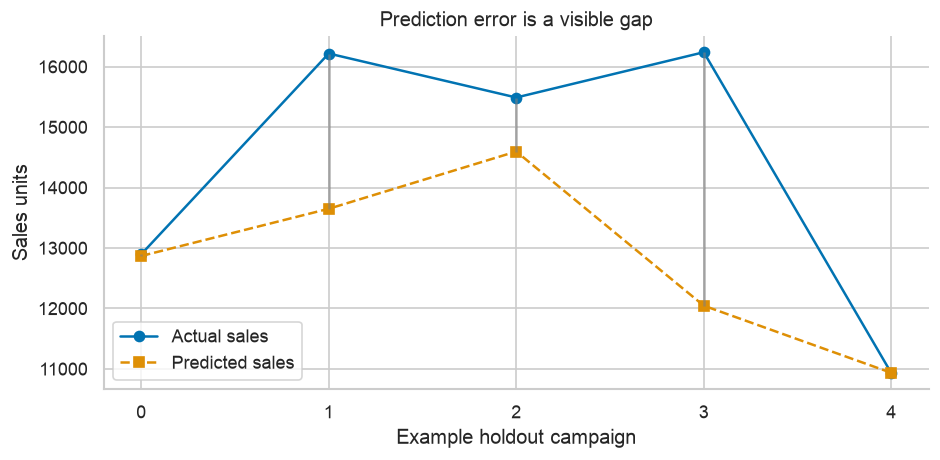

In [72]:
figure, axis = plt.subplots(figsize=(8, 4))
axis.plot(error_examples.index, error_examples["Actual sales"], "o-", label="Actual sales")
axis.plot(error_examples.index, error_examples["Predicted sales"], "s--", label="Predicted sales")
axis.vlines(error_examples.index, error_examples["Actual sales"], error_examples["Predicted sales"], color="gray", alpha=0.6)
axis.set(xticks=error_examples.index, xlabel="Example holdout campaign", ylabel="Sales units", title="Prediction error is a visible gap")
axis.legend()
display_figure(figure)

#### Plot 1: are predictions near the correct values?

A perfect forecast lies on the dashed diagonal. A point above the line is an overprediction; a point below it is an underprediction.

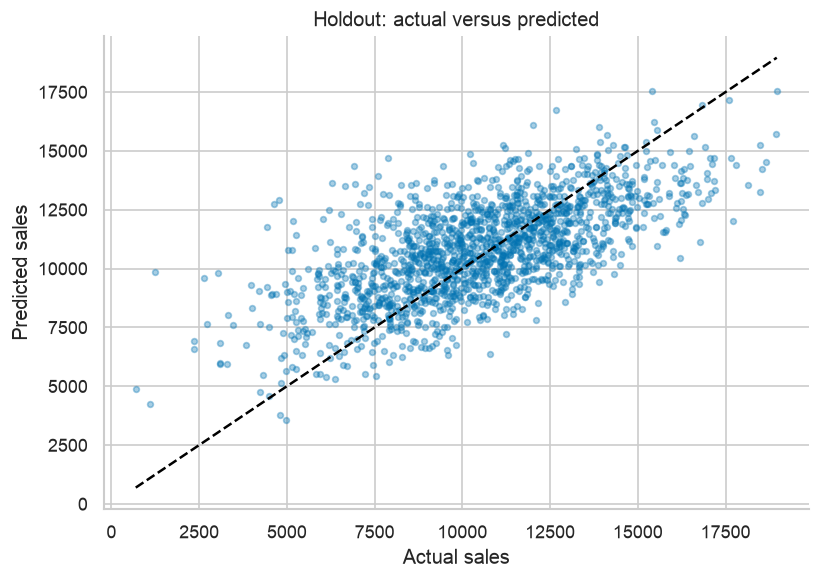

In [73]:
holdout_residuals = holdout_sales.to_numpy() - holdout_predictions
figure, axis = plt.subplots(figsize=(7, 5))
axis.scatter(holdout_sales, holdout_predictions, s=12, alpha=0.35)
sales_axis_limits = [min(holdout_sales.min(), holdout_predictions.min()), max(holdout_sales.max(), holdout_predictions.max())]
axis.plot(sales_axis_limits, sales_axis_limits, "--", color="black")
axis.set(xlabel="Actual sales", ylabel="Predicted sales", title="Holdout: actual versus predicted")
display_figure(figure)

#### Plot 2: look for systematic errors

Here, residual = actual − predicted. Positive values mean the model underestimated sales. A curved pattern would suggest a missed relationship; widening spread would suggest growing uncertainty.

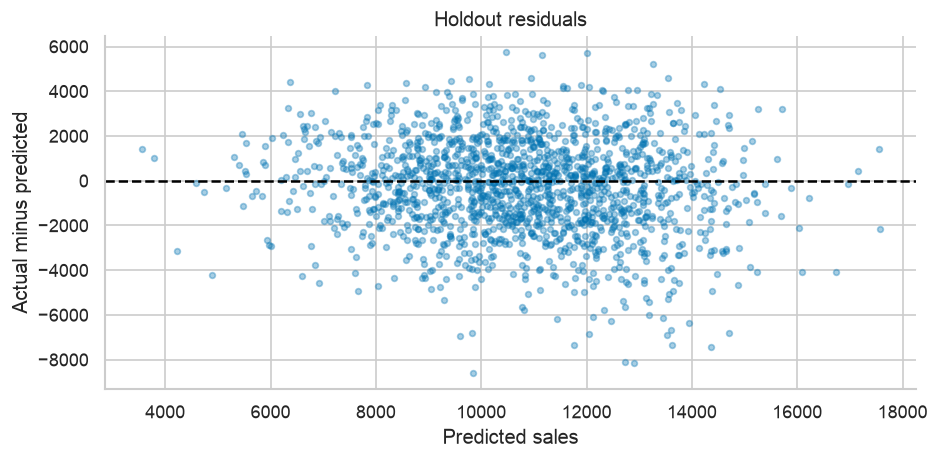

In [74]:
figure, axis = plt.subplots(figsize=(8, 4))
axis.scatter(holdout_predictions, holdout_residuals, s=12, alpha=0.35)
axis.axhline(0, color="black", linestyle="--")
axis.set(xlabel="Predicted sales", ylabel="Actual minus predicted", title="Holdout residuals")
display_figure(figure)

#### Plot 3: how common are large errors?

Values near zero are small misses. Long tails show why RMSE can exceed MAE even when many forecasts are reasonable.

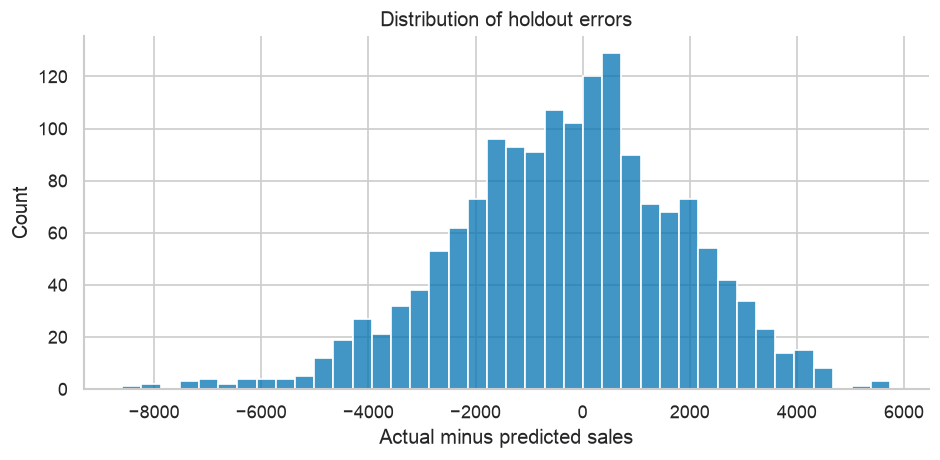

In [75]:
figure, axis = plt.subplots(figsize=(8, 4))
sns.histplot(holdout_residuals, bins=40, ax=axis)
axis.set(xlabel="Actual minus predicted sales", title="Distribution of holdout errors")
display_figure(figure)

#### Plot 4: a forecast is a range of possible outcomes

The blue band is the calibrated interval for the development-fitted model. Some actual outcomes fall outside it. The interval is not a guarantee for each individual campaign.

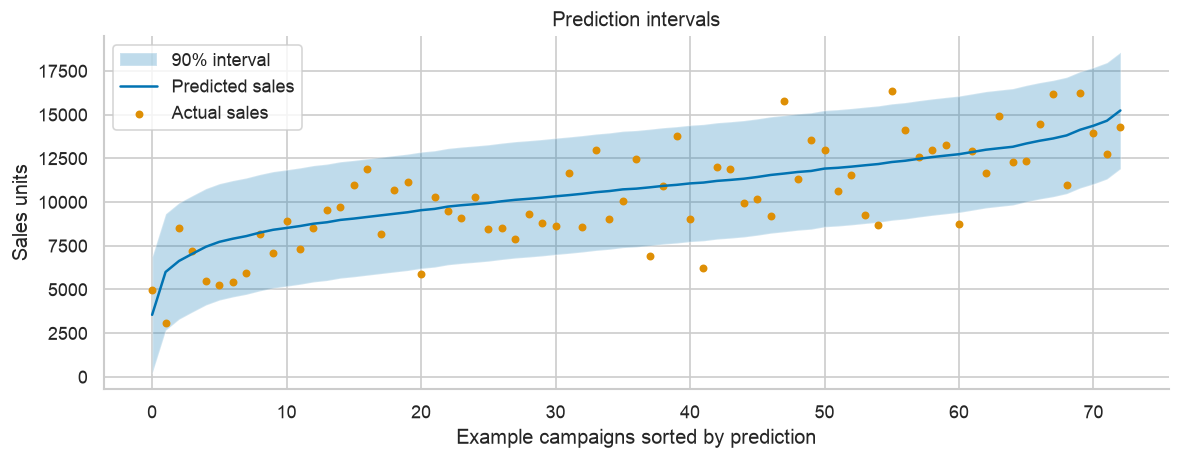

In [76]:
ordered_sample_indices = np.argsort(holdout_predictions)[::max(1, len(holdout_predictions)//70)]
figure, axis = plt.subplots(figsize=(10, 4))
axis.fill_between(np.arange(len(ordered_sample_indices)), interval_lower_bounds[ordered_sample_indices], interval_upper_bounds[ordered_sample_indices], alpha=0.25, label="90% interval")
axis.plot(holdout_predictions[ordered_sample_indices], label="Predicted sales")
axis.scatter(np.arange(len(ordered_sample_indices)), holdout_sales.to_numpy()[ordered_sample_indices], s=14, label="Actual sales")
axis.set(xlabel="Example campaigns sorted by prediction", ylabel="Sales units", title="Prediction intervals")
axis.legend()
display_figure(figure)

#### Separate campaigns by input completeness

In [77]:
holdout_cleaner=CampaignCleaner(follower_mode=selected_follower_policy).fit(development_campaigns)
cleaned_holdout_campaigns=holdout_cleaner.transform(holdout_campaigns)
input_quality_groups=pd.Series(np.where(cleaned_holdout_campaigns.isna().any(axis=1),"At least one imputed input","Complete valid inputs"),index=holdout_campaigns.index)
quality_group_errors=[]
for name in input_quality_groups.unique():
    group_mask=input_quality_groups.eq(name).to_numpy()
    quality_group_errors.append({"segment":name,"n":int(group_mask.sum()),**calculate_regression_scores(holdout_sales.to_numpy()[group_mask],holdout_predictions[group_mask]),
                           "90% coverage":float(np.mean((holdout_sales.to_numpy()[group_mask]>=interval_lower_bounds[group_mask])&(holdout_sales.to_numpy()[group_mask]<=interval_upper_bounds[group_mask])))})
quality_group_errors=pd.DataFrame(quality_group_errors)

#### Compare the errors and interval coverage in each group

In [78]:
display(quality_group_errors.round(3))

,segment,n,RMSE,MAE,R2,90% coverage
0,At least one imputed input,258,2910.384,2228.439,-0.001,0.771
1,Complete valid inputs,1342,1978.994,1588.500,0.500,0.906


#### Visualize the difference in reliability

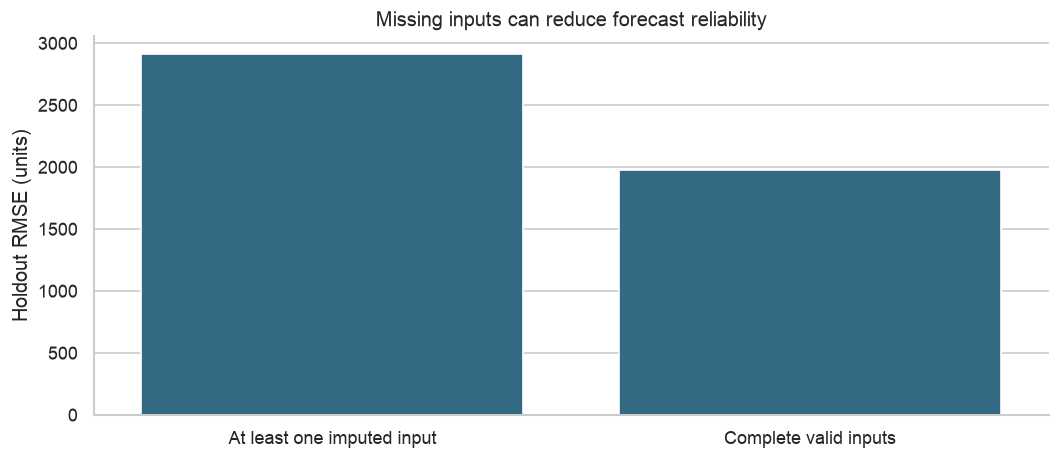

In [79]:
figure,axis=plt.subplots(figsize=(9,4))
sns.barplot(data=quality_group_errors,x="segment",y="RMSE",ax=axis,color="#276E90")
axis.set(title="Missing inputs can reduce forecast reliability",xlabel="",ylabel="Holdout RMSE (units)")
display_figure(figure)

#### Inspect the largest errors without deleting them

In [80]:
largest_error_campaigns=holdout_campaigns.copy()
largest_error_campaigns["Actual sales"]=holdout_sales
largest_error_campaigns["Predicted sales"]=holdout_predictions
largest_error_campaigns["Absolute error"]=np.abs(holdout_residuals)
display(largest_error_campaigns.nlargest(8,"Absolute error")[["ID"]+PREDICTOR_COLUMNS+["Actual sales","Predicted sales","Absolute error"]].round(2))

,ID,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality,Actual sales,Predicted sales,Absolute error
811,5321,NaN,0.6480985862972266,1661.9330646414287,5.16,1242,9840.12,8598.12
3806,49,NaN,3.846953063180949,4827.8167675481745,4.94,4766,12892.86,8126.86
6800,1750,NaN,4.861589587061171,4067.3514686167514,6.10,4623,12724.10,8101.10
6595,38,NaN,1.3143787879010105,7401.678028458903,4.61,6917,14360.10,7443.10
3929,3907,NaN,4.917953080390846,5469.575073228079,5.07,6274,13628.04,7354.04
3915,4990,NaN,0.8648371226628445,4736.605798005571,2.54,4442,11768.90,7326.90
3096,4106,91172.0,2.9714904494908865,3825.585381091424,7.31,2631,9586.86,6955.86
5827,1573,NaN,4.497942673148432,6320.321209436265,1.61,6647,13523.52,6876.52


### Residual interpretation

The diagonal plot shows calibration across sales levels; a systematic bend would suggest a missed nonlinear relationship. Residual spread reveals whether errors grow with expected sales. Normal residuals are not required for useful prediction or conformal calibration. The quality-segment table is particularly important: a single global interval may conceal poor coverage when a major input is missing. Inspect the largest misses to prioritize data collection rather than deleting them to improve the score. No model changes are made after these diagnostics.

### What the holdout outputs actually say

The model's holdout **RMSE is 2,156.6 units** and **MAE is 1,691.7 units**. Large errors make RMSE higher than MAE. R² is **0.415**, so the model explains a useful but limited share of sales variation. The average forecast is informative, but individual campaigns can still miss by several thousand units.

The input-quality split is especially revealing:

| Holdout group | Campaigns | RMSE | Nominal 90% interval coverage |
|---|---:|---:|---:|
| Complete valid inputs | 1,342 | About 1,979 units | 90.6% |
| At least one imputed input | 258 | About 2,910 units | 77.1% |

These are descriptive group comparisons, not evidence that imputation alone causes the difference: the groups may also differ in underlying campaign characteristics. Nevertheless, the incomplete-input forecasts are clearly less reliable in this evaluation.

**Practical decision:** obtain missing reach and spend information before using a forecast for a consequential inventory or budget decision. A global interval can look acceptable while failing to protect an important subgroup.

### An important validation artifact: missing followers concentrate in the holdout

The reserved split unexpectedly contains **all 160 training records with originally missing followers**. Development and calibration contain none. The table below exposes this imbalance; it explains why development CV understates the difficulty of the random holdout and why interval coverage is worse for incomplete campaigns. This concentration is consistent with a shared seed/order artifact in synthetic corruption and splitting, but the data-generation code is unavailable, so its cause is unverified.

We retain the original holdout and its reported score, rather than choosing a new split after seeing its performance. To assess stability under a more balanced availability mix, the later diagnostic evaluates the **already frozen specification** with five-fold cross-validation stratified by input availability on all labelled data. Those scores are explicitly post-selection diagnostics, not a replacement independent holdout. Future evaluations should reserve representative availability strata before any model search, or use a genuinely new prospective dataset.

#### Compare missingness across the data subsets

In [81]:
split_missingness=pd.DataFrame({name:frame[PREDICTOR_COLUMNS].isna().mean()*100 for name,frame in
    {"Development":development_campaigns,"Calibration":calibration_campaigns,"Holdout":holdout_campaigns,"Unlabeled test":test_campaigns}.items()}).T
display(split_missingness.round(2).rename_axis("Raw missing cells (%)"))

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality
Raw missing cells (%),,,,
Development,0.0,1.89,1.97,1.88
Calibration,0.0,2.19,2.03,1.95
Holdout,10.0,2.19,2.00,2.44
Unlabeled test,2.0,2.00,2.00,2.00


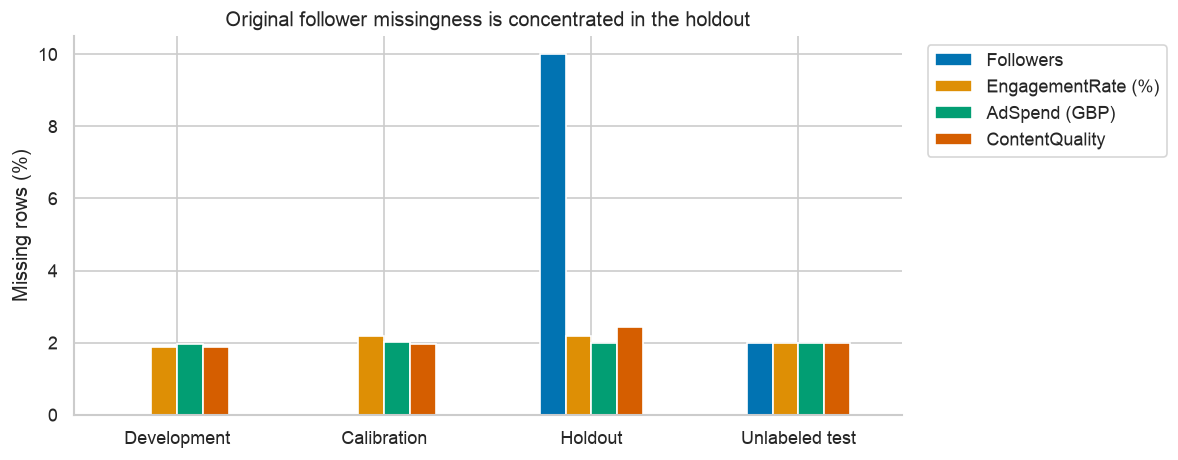

In [82]:
figure,axis=plt.subplots(figsize=(10,4))
split_missingness.plot.bar(ax=axis)
axis.set(title="Original follower missingness is concentrated in the holdout",ylabel="Missing rows (%)",xlabel="")
axis.tick_params(axis="x",rotation=0)
axis.legend(bbox_to_anchor=(1.02,1),loc="upper left")
display_figure(figure)

## 7. Interpretation, stability and deployment limits

### 7.1 Which inputs matter for prediction?

Permutation importance shuffles one **raw input column** at a time on the holdout, then passes it through the entire fitted pipeline. This captures the column's engineered descendants together and measures the increase in RMSE. Ten repeat shuffles measure permutation variability, not a causal confidence interval. Correlated predictors may share credit. Partial-dependence plots show average model response over the central observed range; they do not estimate intervention effects.

#### Shuffle one raw input at a time

In [83]:
permutation_results=permutation_importance(evaluation_model,holdout_campaigns,holdout_sales,scoring="neg_root_mean_squared_error",n_repeats=10,random_state=RANDOM_SEED,n_jobs=1)
feature_importance=pd.DataFrame({"feature":holdout_campaigns.columns,"RMSE increase":permutation_results.importances_mean,"shuffle SD":permutation_results.importances_std})
feature_importance=feature_importance[feature_importance.feature.isin(PREDICTOR_COLUMNS)].sort_values("RMSE increase",ascending=False)
display(feature_importance.round(2))

,feature,RMSE increase,shuffle SD
0,Followers,861.95,46.87
2,AdSpend (GBP),540.77,29.57
3,ContentQuality,115.57,10.00
1,EngagementRate (%),22.11,7.96


#### Plot the loss in accuracy after shuffling

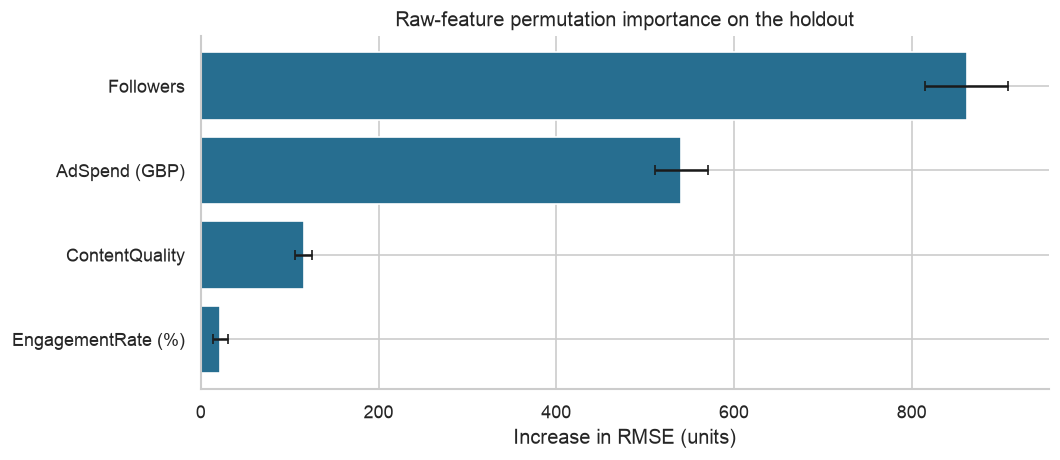

In [84]:
figure,axis=plt.subplots(figsize=(9,4))
sorted_importance=feature_importance.sort_values("RMSE increase")
axis.barh(sorted_importance.feature,sorted_importance["RMSE increase"],xerr=sorted_importance["shuffle SD"],capsize=3,color="#276E90")
axis.set(title="Raw-feature permutation importance on the holdout",xlabel="Increase in RMSE (units)")
display_figure(figure)

#### Calculate an average model-response curve

For one feature, replace its value with a sequence of plausible values, predict the same reference campaigns, and average the results. This is a model explanation, not an experiment on real sales.

In [85]:
reference_campaigns = development_campaigns.sample(n=min(800, len(development_campaigns)), random_state=RANDOM_SEED).copy()
cleaned_reference_campaigns = CampaignCleaner(follower_mode=selected_follower_policy).fit_transform(development_campaigns)

def average_response_curve(feature_name):
    feature_values = np.linspace(cleaned_reference_campaigns[feature_name].quantile(0.05),
                                 cleaned_reference_campaigns[feature_name].quantile(0.95), 25)
    average_sales = []
    for feature_value in feature_values:
        scenario_campaigns = reference_campaigns.copy()
        scenario_campaigns[feature_name] = feature_value
        average_sales.append(np.maximum(evaluation_model.predict(scenario_campaigns), 0).mean())
    return feature_values, average_sales

#### Plot the four response curves

The other inputs are held at the reference campaigns' values. Read the units on each axis; vertical ranges differ between panels.

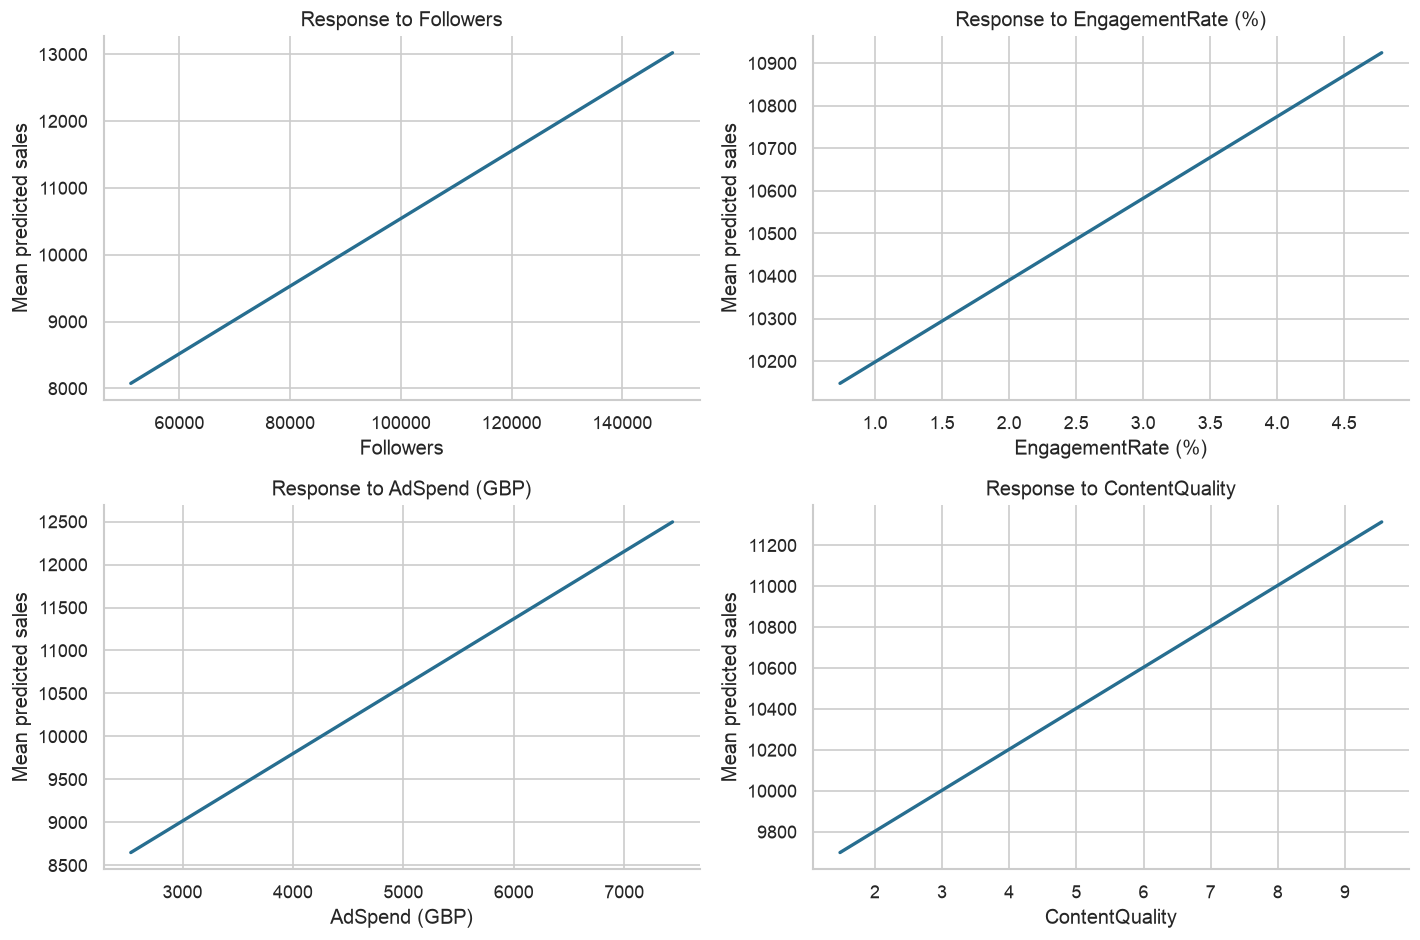

In [86]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, feature_name in zip(axes.flat, PREDICTOR_COLUMNS):
    feature_values, average_sales = average_response_curve(feature_name)
    axis.plot(feature_values, average_sales, color="#276E90", linewidth=2)
    axis.set(xlabel=feature_name, ylabel="Mean predicted sales", title=f"Response to {feature_name}")
display_figure(figure)

### Translate importance into a business interpretation

Shuffling followers increases holdout RMSE by about **862 units**, while shuffling spend increases it by about **541**. The increases for quality and engagement are about **116** and **22** respectively. This ranks predictive dependence as **followers → spend → content quality → engagement** for this fitted model and dataset.

A small permutation score does not mean a feature is unimportant in every campaign, and it is not a causal return-on-investment estimate. For example, engagement could matter differently in other influencer populations or product categories.

The average-response plots are broadly straight because the selected model is additive. The plots use the central 5th–95th percentile input range to avoid presenting extreme extrapolation. Compare each panel's vertical scale before judging effect size: they do not all use the same y-axis limits.

### Interpret an additive model in familiar units

For the selected Huber model, we can undo standardization and express each coefficient as a predicted sales difference for a practical input change. Other model inputs are held constant, and the example assumes valid, observed values rather than missing-value replacements.

These are **model associations**, not promises of incremental sales. They are useful for explaining how a forecast changes; they should not be used as causal budget-allocation rules.

#### Convert standardized coefficients back to original input units

In [87]:
if isinstance(evaluation_model, Pipeline) and isinstance(evaluation_model.named_steps["model"], (HuberRegressor, Ridge)):
    feature_names = evaluation_model.named_steps["features"].get_feature_names_out()
    original_unit_weights = (evaluation_model.named_steps["model"].coef_ /
                             evaluation_model.named_steps["scale"].scale_)
    coefficient_lookup = pd.Series(original_unit_weights, index=feature_names)
    increments = {"Followers": 10000, "EngagementRate (%)": 1,
                  "AdSpend (GBP)": 1000, "ContentQuality": 1}
    interpretations = pd.DataFrame({"Input increase": increments,
        "Predicted sales difference (units)": {
            name: coefficient_lookup[name] * change for name, change in increments.items()}})
    display(interpretations.round(2))
else:
    print("For this selected family, interpret the response plots instead of additive coefficients.")

,Input increase,Predicted sales difference (units)
Followers,10000,505.63
EngagementRate (%),1,192.13
AdSpend (GBP),1000,784.30
ContentQuality,1,200.22


#### Visualize the additive model associations

The input changes differ in size: 10,000 followers, £1,000 spend, or one point of engagement/quality. This is an explanation of model behavior, not a causal sales forecast for an intervention.

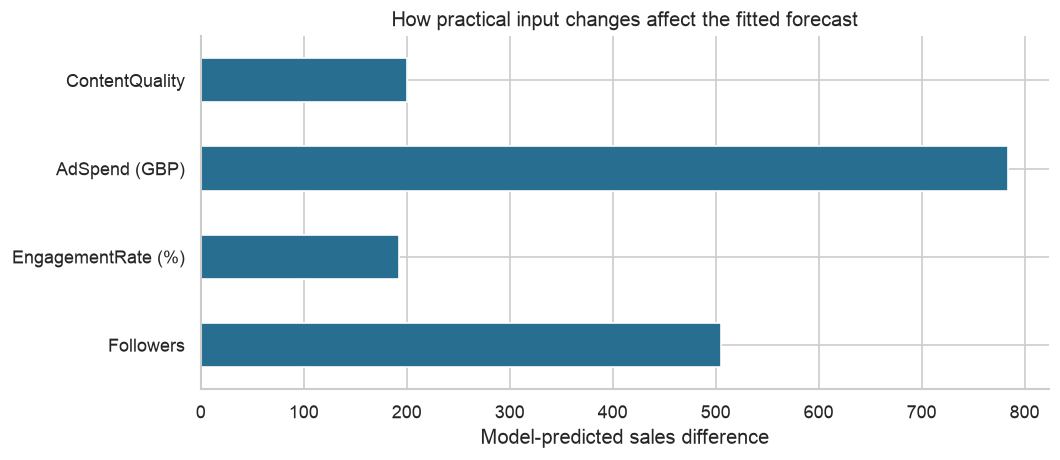

In [88]:
figure, axis = plt.subplots(figsize=(9, 4))
interpretations["Predicted sales difference (units)"].plot.barh(ax=axis, color="#276E90")
axis.set(xlabel="Model-predicted sales difference", title="How practical input changes affect the fitted forecast")
display_figure(figure)

### 7.2 Chronological backtest

The competition test dates overlap training, but deployment usually moves forward in time. Use development campaigns only and three expanding-window splits over **unique dates**, so campaigns on the same day cannot straddle a boundary. Refit the frozen specification on each past window. Since the specification was selected using all development rows, this is a retrospective sensitivity check rather than an independent temporal estimate. A prospective holdout remains necessary.

#### Validate on later campaigns using only past dates

In [89]:
campaign_dates=pd.to_datetime(development_campaigns.Timestamp,errors="raise")
distinct_campaign_dates=np.sort(campaign_dates.unique())
temporal_fold_results=[]

#### Plot the chronological validation errors

In [90]:
for fold,(past,future) in enumerate(TimeSeriesSplit(n_splits=3).split(distinct_campaign_dates),1):
    past_row_indices=np.flatnonzero(campaign_dates.isin(distinct_campaign_dates[past])); future_row_indices=np.flatnonzero(campaign_dates.isin(distinct_campaign_dates[future]))
    fold_model=clone(selected_model_specification).fit(development_campaigns.iloc[past_row_indices],development_sales.iloc[past_row_indices])
    fold_predictions=np.maximum(fold_model.predict(development_campaigns.iloc[future_row_indices]),0)
    temporal_fold_results.append({"fold":fold,"train_n":len(past_row_indices),"valid_n":len(future_row_indices),
                      "train_end":str(pd.Timestamp(distinct_campaign_dates[past][-1]).date()),
                      "valid_start":str(pd.Timestamp(distinct_campaign_dates[future][0]).date()),**calculate_regression_scores(development_sales.iloc[future_row_indices],fold_predictions)})
temporal_results=pd.DataFrame(temporal_fold_results)
display(temporal_results.round(3))

,fold,train_n,valid_n,train_end,valid_start,RMSE,MAE,R2
0,1,1284,1252,2021-09-07,2021-09-08,2026.375,1605.468,0.464
1,2,2536,1268,2022-05-15,2022-05-16,1983.734,1581.269,0.501
2,3,3804,1316,2023-01-21,2023-01-22,2021.865,1612.533,0.486


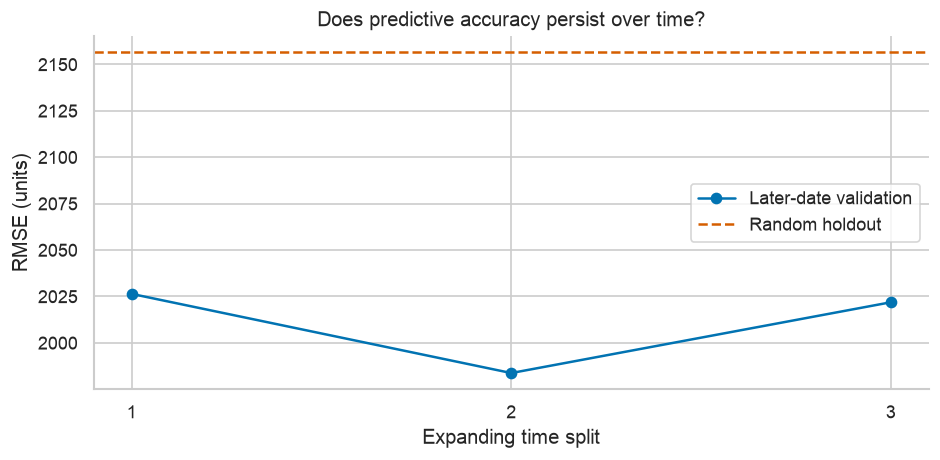

In [91]:
figure,axis=plt.subplots(figsize=(8,4))
axis.plot(temporal_results.fold,temporal_results.RMSE,marker="o",label="Later-date validation")
axis.axhline(holdout_scores["RMSE"],ls="--",color="#D55E00",label="Random holdout")
axis.set(xticks=temporal_results.fold,xlabel="Expanding time split",ylabel="RMSE (units)",title="Does predictive accuracy persist over time?")
axis.legend()
display_figure(figure)

### 7.3 Formatting invariance and corruption stress

First verify that equivalent strings (for example `£5,000` versus `5000`) produce identical forecasts. Next convert 10% of eligible follower values to rounded thousands, independently format 10% of rates and spend, and inject 0.5% invalid follower/spend cells in a copy of the holdout. This approximates the more heavily corrupted test input style; it does not simulate every possible shift. Rounding followers intentionally loses precision, so this stress test need not be exactly invariant. Holdout labels are unchanged and there is no retraining or model selection.

#### Change formatting without changing measurement meaning

In [92]:
equivalent_format_campaigns=holdout_campaigns.copy()
for column_name in PREDICTOR_COLUMNS:
    equivalent_format_campaigns[column_name]=equivalent_format_campaigns[column_name].astype(object)
    numeric_values=pd.to_numeric(equivalent_format_campaigns[column_name],errors="coerce")
    valid_number_mask=numeric_values.notna()
    if column_name=="AdSpend (GBP)": equivalent_format_campaigns.loc[valid_number_mask,column_name]=numeric_values[valid_number_mask].map(lambda v:f"£{v}")
    if column_name=="EngagementRate (%)": equivalent_format_campaigns.loc[valid_number_mask,column_name]=numeric_values[valid_number_mask].map(lambda v:f"{v}%")
assert np.allclose(evaluation_model.predict(equivalent_format_campaigns),evaluation_model.predict(holdout_campaigns),rtol=1e-10,atol=1e-7)
corrupted_campaigns=holdout_campaigns.copy()

#### Create a deliberately messier copy of the holdout

In [93]:
random_generator=np.random.default_rng(RANDOM_SEED+2)
for column_name in PREDICTOR_COLUMNS:
    corrupted_campaigns[column_name]=corrupted_campaigns[column_name].astype(object)
for column_name,sign in [("AdSpend (GBP)","£"),("EngagementRate (%)","%")]:
    numeric_values=pd.to_numeric(corrupted_campaigns[column_name],errors="coerce")
    formatted_row_indices=random_generator.choice(corrupted_campaigns.index[numeric_values.notna()],size=int(.10*len(corrupted_campaigns)),replace=False)
    corrupted_campaigns.loc[formatted_row_indices,column_name]=numeric_values.loc[formatted_row_indices].map(lambda v: f"{sign}{v}" if sign=="£" else f"{v}{sign}")
follower_numbers=pd.to_numeric(corrupted_campaigns.Followers,errors="coerce")
eligible_rows=corrupted_campaigns.index[follower_numbers.between(1000,1e6)]

#### Inject ambiguous follower scales and invalid measurements

In [94]:
rescaled_row_indices=random_generator.choice(eligible_rows,size=int(.10*len(corrupted_campaigns)),replace=False)
corrupted_campaigns.loc[rescaled_row_indices,"Followers"]=(follower_numbers.loc[rescaled_row_indices]/1000).round()
invalid_follower_indices=random_generator.choice(corrupted_campaigns.index,size=max(1,int(.005*len(corrupted_campaigns))),replace=False)
corrupted_campaigns.loc[invalid_follower_indices,"Followers"]=1.8e9
invalid_spend_indices=random_generator.choice(corrupted_campaigns.index,size=max(1,int(.005*len(corrupted_campaigns))),replace=False)
corrupted_campaigns.loc[invalid_spend_indices,"AdSpend (GBP)"]=-5000
corrupted_predictions=np.maximum(evaluation_model.predict(corrupted_campaigns),0)
corruption_scores=calculate_regression_scores(holdout_sales,corrupted_predictions)
display(pd.DataFrame([holdout_scores,corruption_scores],index=["Original holdout","Additional corruption"]).round(3))

,RMSE,MAE,R2
Original holdout,2156.556,1691.690,0.415
Additional corruption,2159.086,1693.806,0.413


#### Measure the effect without retraining

In [95]:
print("Equivalent-format prediction check passed.")

Equivalent-format prediction check passed.


### 7.4 Availability-balanced sensitivity analysis of the frozen model

Stratify on three input-only groups: missing followers, another missing core input, and complete raw inputs. Three reproducible seeds give 15 fold evaluations. Each fold refits cleaning, medians and the frozen model on its training rows. This experiment occurs **after selection and holdout reporting** and cannot establish an independent performance estimate. It checks whether the score changes when the observed availability pattern is represented in every validation fold. No candidate or hyperparameter is changed in response.

#### Balance folds by input availability

In [96]:
from sklearn.model_selection import StratifiedKFold
all_campaigns=training_campaigns.drop(columns=TARGET_COLUMN)
input_availability_groups=np.where(all_campaigns.Followers.isna(),"missing_followers",
                      np.where(all_campaigns[PREDICTOR_COLUMNS].isna().any(axis=1),"other_missing","complete"))
balanced_fold_results=[]

#### Evaluate the frozen model across three fold assignments

In [97]:
for seed in [17,83,211]:
    splits=list(StratifiedKFold(5,shuffle=True,random_state=seed).split(all_campaigns,input_availability_groups))
    result=cross_validate(selected_model_specification,all_campaigns,training_sales,cv=splits,scoring=evaluation_metrics,n_jobs=1)
    for fold in range(5):
        balanced_fold_results.append({"seed":seed,"fold":fold+1,"RMSE":-result["test_rmse"][fold],
                              "MAE":-result["test_mae"][fold],"R2":result["test_r2"][fold]})
balanced_validation_results=pd.DataFrame(balanced_fold_results)
display(balanced_validation_results.round(3))
display(balanced_validation_results[["RMSE","MAE","R2"]].agg(["mean","std"]).round(3))

,seed,fold,RMSE,MAE,R2
0,17,1,2021.321,1599.171,0.498
1,17,2,2053.318,1643.721,0.464
2,17,3,2000.872,1605.838,0.487
3,17,4,1953.396,1557.656,0.510
4,17,5,1964.631,1553.462,0.507
5,83,1,2017.506,1617.356,0.486
6,83,2,1994.552,1590.739,0.494
7,83,3,1997.054,1583.279,0.479
8,83,4,1992.489,1577.150,0.478
9,83,5,1997.275,1592.997,0.521


,RMSE,MAE,R2
mean,1999.557,1592.542,0.492
std,32.379,28.767,0.020


#### Summarize this post-selection sensitivity check

**Post-selection sensitivity:** mean RMSE 1,999.6 units and mean R² 0.492 across the 15 availability-balanced folds. Folds are dependent and their SD is not a confidence interval. The independent original holdout result remains unchanged.

## 8. Train the final model and predict new campaigns

The model specification is now fixed. Refit it on **all 8,000 labelled campaigns**, so the final point predictor can learn from every available labelled example, including campaigns with missing followers.

This final refit uses rows that were previously reserved for calibration and evaluation. Therefore, we do not score it on those same rows and call the result a new holdout score. The earlier evaluation remains the evidence for generalization.

The 2,000 supplied test campaigns have no target labels. We can display their predictions and check their scale, but we cannot calculate a genuine test RMSE or R².

### A simple function for future messy inputs

`predict_campaign_sales(data, model)` accepts campaign rows as a DataFrame or CSV path and uses the already fitted pipeline. It returns:

- Predicted sales, with the original row order and optional ID preserved.
- The number of core inputs that required imputation.
- Whether a small bare follower value was assumed to represent thousands.
- A review flag for either kind of uncertainty.

The function never learns medians or refits a model on future rows. Missing cells are supported, but the four predictor columns must be present. A completely unknown campaign can receive a numerical fallback; that does not make the forecast informative, so it is flagged for review.

The calibrated interval belongs to the earlier development-fitted model. We do not attach that interval to the all-data refit, because the model has changed.

#### Accept either a table or a CSV path

This helper reads inputs only. It does not fit or change the model.

In [98]:
def read_prediction_inputs(data):
    if isinstance(data, (str, bytes)) or hasattr(data, "__fspath__"):
        campaigns = pd.read_csv(data)
    else:
        campaigns = data.copy()
    check_campaign_columns(campaigns)
    if campaigns.empty:
        raise ValueError("Provide at least one campaign.")
    return campaigns

#### Explain which rows need input review

A numerical prediction can still rely on uncertain input assumptions. These flags make that visible.

In [99]:
def prediction_quality_flags(campaigns, fitted_model):
    pipeline = fitted_model.estimators_[0] if hasattr(fitted_model, "estimators_") else fitted_model
    cleaner = pipeline.named_steps["clean"]
    cleaned = cleaner.transform(campaigns)
    flags = pd.DataFrame(index=campaigns.index)
    flags["imputed_features"] = cleaned.isna().sum(axis=1)
    follower_counts = pd.to_numeric(campaigns["Followers"], errors="coerce")
    small_counts = follower_counts.between(0, 1000, inclusive="neither")
    flags["follower_scale_assumed"] = small_counts & (cleaner.follower_mode == "scale")
    flags["review_required"] = (flags.imputed_features > 0) | flags.follower_scale_assumed
    return flags

#### Predict with one short, reusable function

The model is already fitted. This function applies it and joins the predictions to the original IDs and review flags.

In [100]:
def predict_campaign_sales(data, fitted_model):
    campaigns = read_prediction_inputs(data)
    sales_predictions = np.maximum(fitted_model.predict(campaigns), 0)
    if not np.isfinite(sales_predictions).all():
        raise ValueError("The model returned an invalid prediction.")
    forecasts = pd.DataFrame(index=campaigns.index)
    if "ID" in campaigns:
        forecasts["ID"] = campaigns["ID"]
    forecasts["Sales (Units)"] = sales_predictions
    return forecasts.join(prediction_quality_flags(campaigns, fitted_model))

#### Fit on all labelled data and inspect the test forecasts

In [101]:
final_model = clone(selected_model_specification).fit(training_campaigns.drop(columns=TARGET_COLUMN), training_sales)
predictions = predict_campaign_sales(test_campaigns, final_model)
test_sales_predictions = predictions[["ID", TARGET_COLUMN]].copy()
display(test_sales_predictions.head(15).round(2))
display(test_sales_predictions[TARGET_COLUMN].describe().to_frame("Test sales predictions").round(2))
print(f"Predicted all {len(test_sales_predictions):,} test campaigns.")
print(f"Campaigns needing input review: {predictions.review_required.sum():,}")
display(predictions.loc[predictions.review_required].head(10).round(2))

,ID,Sales (Units)
0,6252,12984.77
1,4684,8936.24
2,1731,10139.06
3,4742,10877.36
4,4521,11632.50
5,6340,9323.72
6,576,10343.06
7,5202,11953.12
8,6363,12526.04
9,439,14126.32


,Test sales predictions
count,2000.00
mean,10524.67
std,1970.76
min,4623.65
25%,9192.83
50%,10524.92
75%,11822.38
max,16867.42


Predicted all 2,000 test campaigns.
Campaigns needing input review: 355


,ID,Sales (Units),imputed_features,follower_scale_assumed,review_required
6,576,10343.06,1,False,True
7,5202,11953.12,0,True,True
9,439,14126.32,0,True,True
13,5653,13172.64,0,True,True
29,8847,10056.69,1,False,True
34,8328,9562.47,1,False,True
56,3039,9115.34,1,False,True
60,1188,13497.67,0,True,True
64,1315,5766.97,0,True,True
65,8187,10949.62,1,False,True


### Try the function on four different input situations

1. A valid campaign using explicit `k`, percent and currency formats.
2. An ambiguous small follower count and invalid negative spend.
3. A campaign with all four measurements missing.
4. Unrecognized text and an out-of-range quality rating.

The purpose is to show the cleaning behavior, not to suggest that equally reliable forecasts can be made for all four cases. Compare the returned review flags with the raw examples.

#### Try the four illustrative campaigns

In [102]:
example_campaigns = pd.DataFrame({"Followers": ["120k", 95, None, "invalid"],
    "EngagementRate (%)": ["3.2%", 2.5, None, "bad"],
    "AdSpend (GBP)": ["£5,000", -100, None, "£4,000"],
    "ContentQuality": [8, 7, None, 11]})
display(example_campaigns)
display(predict_campaign_sales(example_campaigns, final_model).round(2))

,Followers,EngagementRate (%),AdSpend (GBP),ContentQuality
0,120k,3.2%,"£5,000",8.0
1,95,2.5,-100,7.0
2,None,None,None,NaN
3,invalid,bad,"£4,000",11.0


,Sales (Units),imputed_features,follower_scale_assumed,review_required
0,12100.25,0,False,False
1,10047.96,1,True,True
2,10783.85,4,False,True
3,10473.29,3,False,True


#### Compare predicted and observed sales distributions

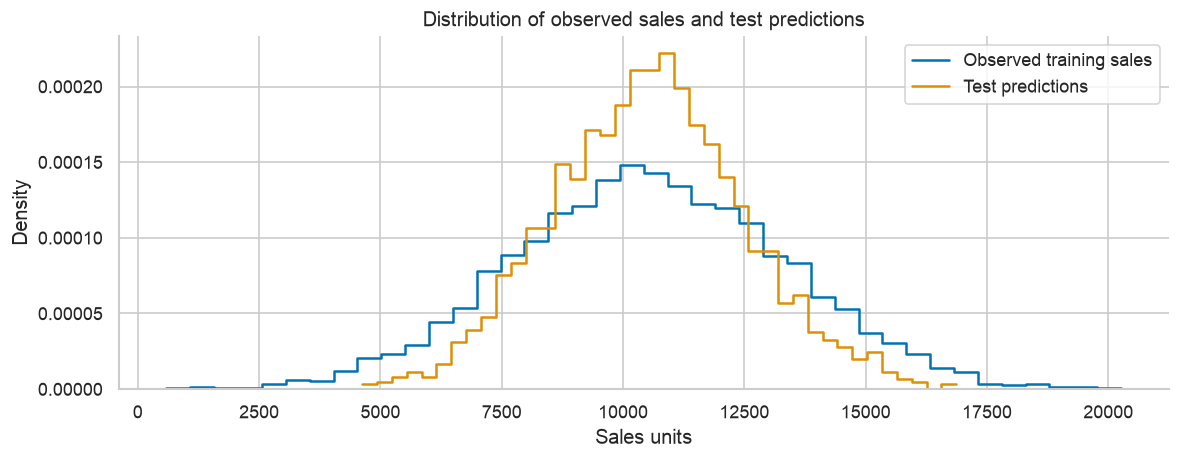

In [103]:
figure, axis = plt.subplots(figsize=(10, 4))
sns.histplot(training_sales, bins=40, stat="density", element="step", fill=False,
             label="Observed training sales", ax=axis)
sns.histplot(test_sales_predictions[TARGET_COLUMN], bins=40, stat="density", element="step", fill=False,
             label="Test predictions", ax=axis)
axis.set(title="Distribution of observed sales and test predictions", xlabel="Sales units")
axis.legend()
display_figure(figure)

### What can we conclude from the final predictions?

The prediction distribution is narrower than the observed sales distribution. This is expected for a model estimating average sales conditional on a few inputs: it cannot reproduce unpredictable campaign-level variation. A narrower prediction range is not, by itself, evidence that predictions are wrong or a reason to stretch them artificially.

A distribution plot is a plausibility check, not an accuracy test. We still need observed sales to know which specific test predictions are close.

For future data, confirm input units and feature availability, inspect review flags and compare errors after outcomes become available. Revisit the model when the campaign population or collection process changes.

## 9. Summary, observations and recommendations

The following summary is generated directly from the executed results, so reported numbers remain consistent when the notebook is rerun.

### Results
- **Selected pipeline:** Huber tuned; follower policy: `scale`. Selection used five-fold development CV, followed by a sealed holdout.
- **Holdout:** RMSE **2,156.6 units**, MAE **1,691.7 units**, R² **0.415**. The mean baseline RMSE was **2,820.0 units**.
- **Uncertainty:** the development-fitted model's nominal 90% interval achieved **88.4%** holdout coverage, with half-width **3,331 units**. Check the input-quality segment table before relying on global coverage.
- **Robustness:** chronological RMSE ranged from **1,983.7 to 2,026.4**; the additional-corruption test achieved RMSE **2,159.1**. The chronological check is retrospective and does not replace prospective validation.
- **Final predictions:** 2,000 test predictions retain original IDs and order. 355 records have at least one input-quality or scale-assumption flag.

### What the evidence supports
1. **Followers** has the largest holdout permutation importance. Its disruption most harms predictive accuracy; improve its measurement and availability first.
2. Mixed-scale and formatting errors are more common in test inputs than training inputs. Parsing, fold-fitted outlier handling and explicit scale assumptions are essential parts of the model, not cosmetic cleanup.
3. The initial model table and tuning results quantify the value of nonlinear terms and ensembles. The selected specification wins on development RMSE; no holdout-driven retuning was performed.
4. Missing inputs require imputation and can widen errors. Quality-segment diagnostics and review flags are necessary alongside point forecasts.
5. All 160 originally missing follower records fell in the initial holdout. Development/calibration lacked that raw missingness pattern. The availability-balanced, post-selection sensitivity analysis gives mean RMSE **1,999.6** and R² **0.492**; it does not replace the independent holdout. This imbalance limits calibration transfer, particularly to campaigns with missing followers.
6. Huber, Ridge and their blend are practically tied: the best CV differences are far smaller than the roughly 80-unit fold variation. The nonlinear candidates do not provide evidence of a useful improvement. These data support moderate predictive accuracy, not a claim of high R² or a demonstrated noise ceiling.

### Recommendations
- Use forecasts to screen campaigns and plan inventory within the observed campaign range, paired with uncertainty and input-quality review.
- Standardize followers as absolute counts, engagement as percentage points and spend as numeric GBP at ingestion. Store source-unit metadata rather than repeatedly inferring scale.
- Confirm that historical feature definitions match the values available at prediction time. Test pre-launch planned inputs separately before budget approval use.
- Validate proposed spend or content changes with randomized campaign experiments. Observational prediction does not identify causal sales lift, profitable spend levels or incremental return on investment; revenue and margin data are absent.
- Collect creator/product identifiers, campaign duration, prior sales and timestamped feature snapshots to support grouped validation and stronger prospective forecasts. Keep any post-outcome fields out of features.

### Limitations and next experiments
Hidden test labels and competition scoring rules are unavailable. The test format shift and unverified follower units may affect accuracy. No creator identifier permits grouped validation, and the subjective content-quality score may drift between raters. Cross-validation was reused for candidate and hyperparameter selection; only the holdout score is independent of that selection. Test conformal coverage prospectively, especially on records with missing inputs. An external challenge set with confirmed units and new creators would be more informative than further tuning on this holdout.

### Final learning checkpoints

1. **Why not clean everything once before cross-validation?** Learned medians and cutoffs would then use validation information. Fit them inside the pipeline.
2. **Why not choose the model with the lowest training error?** The objective is to predict unseen campaigns, not memorize historical ones.
3. **Why keep the difficult holdout?** Replacing it after seeing the score would make the reported performance misleading. Investigate its missingness imbalance instead.
4. **Why not multiply every small engagement value by 100?** The source definition says percentage points. An unstated conversion can create a new data error.
5. **Why not promise higher sales when spend increases?** These models learn associations. Causal lift requires additional evidence, such as a randomized experiment.
6. **Why predict decimals for units sold?** The model estimates an expected value, which can be fractional. Rounding is a later business decision.
7. **Why keep a simpler model when complex ones exist?** In these experiments, additional complexity lowered training error without improving unseen-fold error.

**Main lesson:** good case-study work is not just choosing an algorithm. It is making assumptions explicit, comparing them fairly, interpreting errors and knowing what the evidence cannot establish.